# STINTSY Major Course Output

### Group 3
### Members:

* Rohann Gabriel D. Dizon
* Rainier A. Dulatre

### Dataset Description

* The dataset comprises competitive gameplay statistics sourced from **Tetrio**, a modern, fast-paced multiplayer Tetris clone. It specifically tracks the performance and match data of the top 500 players in the Tetra League. The data is scraped from 61,935 match replays of the top 500 Tetra League players between January 22, 2024, and January 30, 2024.

* Source: Kaggle (https://www.kaggle.com/datasets/n3koasakura/tetr-io-top-players-replays/data)

### Structure of the Data
* **Unit of Analysis**: Each individual row represents a single subframe piece placement (one block dropped) 
* **Number of Observations/Rows**: 7,716,524 piece placements.
* **Format**: Tabular data with 21 variables/columns.

### Description of Variables

| **Features/Variables** | **Description** |
|------------------------|-----------------|
| game_id | The unique ID for this game/replay (players in the same match get different IDs). |
| subframe | The subframe of this placement. There 60 frames per second and 10 subframes per frame, or 600 subframes per second, starting with subframe 0. |
| won | 1 if this placement is part of a replay that won its match. Otherwise, 0. |
| playfield | The 10x40 playfield right before the placement occured. The cells of the playfield are ordered left to right, bottom to top. The playfield is truncated once all the remaining cells are empty. An empty string is not a missing value, but instead represents a playfield where all cells are empty. Each cell is represented with the letter of its corresponding tetrimino, except for empty and garbage cells, which are represented with "N" and "G" respectively. |
| x | The x-coordinate of the center of the placed piece according to the "true rotations" used in the Super Rotation System. 0 indicates the leftmost column, 9 indicates the rightmost column. |
| y | The y-coordinate of the center of the placed piece according to the "true rotations" used in the Super Rotation System. 0 indicates the bottommost row, 39 indicates the topmost row. |
| r | The rotation of the placed piece according to the Super Rotation System. N(0) - North; E(R) - East; S(2) - South; W(L) - West  |
| placed | The type of piece placed. |
| hold | The type of piece currently being held. "N" means no piece is being held. |
| next | The types of the next 14 peices in the queue (only the first 5 are visible to the player). |
| cleared | The number of rows cleared with this placement. |
| garbage_cleared | The number of rows containing garbage cleared with this placement. |
| attack | The rows of garbage sent with this placement, before garbage blocking. |
| t_spin | The type of T-spin performed. N - None; M - Mini; F - Full |
| btb | The length of the back-to-back chain right before this placement. |
| combo | The length of the combo chain right before this placement. |
| immediate_garbage | The rows of incoming garbage in queue ready to be received (the actual amount that will be received is capped at 8). |
| incoming_garbage | The total rows of incoming garbage in queue. |
| rating | The player's Tetra League rating (25000 is the maximum rating). |
| glicko | The player's Tetra League Glicko-2 rating. |
| glicko_rd | The player's Tetra League Glicko-2 rating deviation. |

### Variables Used in this Study

This study used **14** of the 21 variables, which are `game_id`, `subframe`, `won`, `cleared`, `garbage_cleared`, `attack`, `t_spin`, `btb`, `combo`, `immediate_garbage`, `incoming_garbage`, `rating`, `glicko`, and `glicko_rd`.The reason for choosing these variables is its relevance to the group's desired prediction task for the models to be tackled later in the notebook. However, note that **these are not the final variables used in model training/validation/testing** as it proceeds through data cleaning and feature engineering.

### Importing Libraries

The following libraries are used throughout the project and are necessary to perform data preprocessing, analysis, visualizations, and model training, validation, and testing:

In [ ]:
# --- IPython Magics ---
%load_ext autoreload
%autoreload 2

# --- Standard Library & System ---
import os
import sys
import itertools
from dotenv import load_dotenv

# --- Data Manipulation & Statistics ---
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, loguniform

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim

# --- Experiment Tracking ---
import comet_ml

# --- Local Project Setup & Custom Modules ---
# Ensure the project root is in the path before importing local modules
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.neural_network import NeuralNetwork
from src.data_loader import DataLoader
from src.kNN import plot_knn_boundary
from src.logreg import MinibatchSGDWrapper

# --- Initializations ---
load_dotenv()
api_key = os.getenv("COMET_API_KEY")
comet_ml.login(api_key=api_key)

exp = comet_ml.start(project_name="logreg-hyperparam-tuning")
exp.set_name("LogReg Hyperparam Tuning")
exp.add_tag("logreg")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Raw Contents of the Dataset

In [25]:
df = pd.read_csv("../data/data.csv")

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7716524 entries, 0 to 7716523
Data columns (total 21 columns):
 #   Column             Dtype  
---  ------             -----  
 0   game_id            int64  
 1   subframe           int64  
 2   won                int64  
 3   playfield          str    
 4   x                  int64  
 5   y                  int64  
 6   r                  str    
 7   placed             str    
 8   hold               str    
 9   next               str    
 10  cleared            int64  
 11  garbage_cleared    int64  
 12  attack             int64  
 13  t_spin             str    
 14  btb                int64  
 15  combo              int64  
 16  immediate_garbage  int64  
 17  incoming_garbage   int64  
 18  rating             float64
 19  glicko             float64
 20  glicko_rd          float64
dtypes: float64(3), int64(12), str(6)
memory usage: 1.2 GB


In [ ]:
df.shape

(7716524, 21)

In [ ]:
df.head()

,game_id,subframe,won,playfield,x,y,r,placed,hold,next,...,garbage_cleared,attack,t_spin,btb,combo,immediate_garbage,incoming_garbage,rating,glicko,glicko_rd
0,1,67,1,NaN,4,0,N,I,N,JZSOTLSLIOJZTJ,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624
1,1,170,1,NNNIIII,4,1,N,Z,J,SOTLSLIOJZTJTZ,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624
2,1,339,1,NNNIIIINNNNNNNZZNNNNNNNZZ,6,1,E,S,J,OTLSLIOJZTJTZS,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624
3,1,472,1,NNNIIIISNNNNNNZZSSNNNNNZZNS,8,0,N,O,J,TLSLIOJZTJTZSO,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624
4,1,602,1,NNNIIIISOONNNNZZSSOONNNZZNS,0,1,E,J,T,LSLIOJZTJTZSOI,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624


The code results above gives us insight about what the data looks like before being preprocessed. This also lets us verify that we are indeed dealing with 7,716,524 rows and 21 columns.

## Data Preprocessing

Prior to data exploration and analysis, data cleaning and preprocessing will be carried out to resolve any discrepancies in the dataset and avoid inaccurate results.

The following was checked and applied with the necessary cleaning procedures:

* Removing Unnecessary Variables
* Multiple Representations
* Missing Data
* Negative Values
* Incorrect Datatypes
* Default Values and Inconsistent Formatting
* Duplicate Data
* Data Inconsistencies
* Outliers
* Feature Engineering

### Removing Unnecessary Variables

As previously mentioned, this study only focused on *14* specific variables that are related to the prediction task, so other columns that are not needed are disregarded, specifically variables related to the spatial playfield.

In [26]:
unneeded_cols = ["playfield", "x", "y", "r", "next", "hold", "placed"]
present_unneeded = [col for col in unneeded_cols if col in df.columns]
df = df.drop(columns=present_unneeded)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7716524 entries, 0 to 7716523
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   game_id            int64  
 1   subframe           int64  
 2   won                int64  
 3   cleared            int64  
 4   garbage_cleared    int64  
 5   attack             int64  
 6   t_spin             str    
 7   btb                int64  
 8   combo              int64  
 9   immediate_garbage  int64  
 10  incoming_garbage   int64  
 11  rating             float64
 12  glicko             float64
 13  glicko_rd          float64
dtypes: float64(3), int64(10), str(1)
memory usage: 824.2 MB


### Checking For Multiple Representations

This is done to check for multiple represenations in the categorical variables that will be used

In [ ]:
df["won"].value_counts()

won
1    4274700
0    3441824
Name: count, dtype: int64

In [ ]:
df["t_spin"].value_counts()

t_spin
N    7150022
F     527604
M      38898
Name: count, dtype: int64

The number of unique labels and values within `won` and `t_spin` are correctly represented and conform with the unique labels defined by the dataset's dictionary

### Checking For Missing Data

This is done to identify missing data or null values in each variable

In [ ]:
df.isnull().any()

game_id              False
subframe             False
won                  False
cleared              False
garbage_cleared      False
attack               False
t_spin               False
btb                  False
combo                False
immediate_garbage    False
incoming_garbage     False
rating               False
glicko               False
glicko_rd            False
dtype: bool

No further processing is required regarding missing data as there are no presence of null values in any of the variables

### Checking for Negative Values

This is done to check for negative values, especially for the variables with a continuous numerical value. Given the context of the dataset and variables, there should ideally be no negative values.

In [ ]:
numeric_cols = df.select_dtypes(include=["number"])
negative_counts = (numeric_cols < 0).sum()
print(negative_counts)

game_id              0
subframe             0
won                  0
cleared              0
garbage_cleared      0
attack               0
btb                  0
combo                0
immediate_garbage    0
incoming_garbage     0
rating               0
glicko               0
glicko_rd            0
dtype: int64


Results show that no negative values were found within the variables

### Checking for Incorrect Datatypes

This is done to check if the variables are currently assigned appropriate variables

In [ ]:
df.dtypes

game_id                int64
subframe               int64
won                    int64
cleared                int64
garbage_cleared        int64
attack                 int64
t_spin                   str
btb                    int64
combo                  int64
immediate_garbage      int64
incoming_garbage       int64
rating               float64
glicko               float64
glicko_rd            float64
dtype: object

It shows that all variables are already assigned the appropriate variables

However, the current variables with numerical datatypes (int and float) could use a smaller-range for memory optimization purposes, especially useful during model training

In [27]:
int_cols = [
    "won",
    "game_id",
    "subframe",
    "cleared",
    "garbage_cleared",
    "attack",
    "btb",
    "combo",
    "immediate_garbage",
    "incoming_garbage",
]
float_cols = ["rating", "glicko", "glicko_rd"]
for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], downcast="integer", errors="coerce")
for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], downcast="float", errors="coerce")

df.dtypes

game_id                int32
subframe               int32
won                     int8
cleared                 int8
garbage_cleared         int8
attack                  int8
t_spin                   str
btb                     int8
combo                   int8
immediate_garbage       int8
incoming_garbage        int8
rating               float32
glicko               float32
glicko_rd            float32
dtype: object

### Checking for Default Values and Inconsistent Formatting

This is done to check for distinct values in every variable and identify whether it contains default values or inconsistent formatting among the values

In [ ]:
for col in df:
    print(f"{col}: {df[col].unique()}")
    print("")

game_id: [     1      2      3 ... 124030 124031 124032]

subframe: [    67    170    339 ... 102556 103224 103661]

won: [1 0]

cleared: [0 2 1 4 3]

garbage_cleared: [0]

attack: [ 0  4  1  5  3  6  2  7  8 10  9 11 12 14 15 16 17 13 19 18 22 20]

t_spin: <StringArray>
['N', 'F', 'M']
Length: 3, dtype: str

btb: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54]

combo: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]

immediate_garbage: [ 0  7  8  4  2  1  6 10 13  5  3  9 11 15 12 14 20 16 19 23 22 18 28 17
 21 26 25 24 31 27 32 36 30 40 35 41 33 29 34 38 37 69 78 49 42 50 43 51
 39 46 59 58 77 61 52 56]

incoming_garbage: [ 0  7 15  9  2  1  4  6  5  3 13 10 11  8 16 12 14 18 20 19 23 29 17 28
 22 24 21 26 25 27 31 32 34 36 30 40 35 41 33 38 37 69 78 49 42 50 43 51
 39 46 66 58 77 74 52 56 59 44]

rating: [24748.521 24820.71  24788.744 24830.146 

Based from the results, there are no default values nor inconsistent formatting present in any of the variables

However, it can be seen that the only value for `garbage_cleared` is **0**, which makes it essentially useless and unnecessary to keep moving forward.

In [28]:
df = df.drop(columns=['garbage_cleared'])

### Checking for Duplicate Data

This is done to check for any rows that have the exact same values

In [ ]:
df.duplicated().any()

True

Results show that there are rows with the exact same values, which should not be possible especially if rows in one game contain the same subframes as it is physically impossible to have two or more pieces placed within the same subframe

In [29]:
df = df.drop_duplicates(subset=["game_id", "subframe"])
df.shape

(7716512, 13)

This shows that 12 rows have been removed from the intial amount of rows after duplicate rows with the same `game_id` and `subframe`

### Checking for Inconsistent Games

This is to check for inconsistencies within the games. Variables like a player's starting `rating`, `glicko`, `glicko_rd`, and whether they `won` the match should be identical for every single piece placed within the same game

In [ ]:
if {"game_id", "won", "rating", "glicko", "glicko_rd"}.issubset(df.columns):
    gchecks = df.groupby("game_id")[["won", "rating", "glicko", "glicko_rd"]].nunique()
    inconsistent_games = gchecks[(gchecks > 1).any(axis=1)].index.tolist()
    print(f"Inconsistent games found: {len(inconsistent_games)}")
    df = df[~df["game_id"].isin(inconsistent_games)]

Inconsistent games found: 0


Based on the results, no inconsistencies where found within the games

### Checking for Outliers

This is done to check for outliers within the numerical variables the will be used. This was done through statistical and frequency-based outlier detection, specifically doing a percentile and frequency check. This process was chosen over using visualizations since we are dealing with 7.7 million rows for now

In [ ]:
num_cols = [
    "cleared",
    "attack",
    "btb",
    "combo",
    "immediate_garbage",
    "incoming_garbage",
]
for col in num_cols:
    if col in df.columns:
        high = df[col].quantile(0.999)
        low = df[col].quantile(0.001)
        print(f"{col}: min={df[col].min()}, max={
              df[col].max()}, 0.1%={low}, 99.9%={high}")

for col in num_cols:
    if col in df.columns:
        top_values = df[col].value_counts().nlargest(5).to_dict()

        max_val = df[col].max()

        print(f"--- {col} ---")
        print(f"Max Value: {max_val}")
        print(f"Top 5 most common values: {top_values}\n")

cleared: min=0, max=4, 0.1%=0.0, 99.9%=4.0
attack: min=0, max=22, 0.1%=0.0, 99.9%=7.0
btb: min=0, max=54, 0.1%=0.0, 99.9%=19.0
combo: min=0, max=21, 0.1%=0.0, 99.9%=7.0
immediate_garbage: min=0, max=78, 0.1%=0.0, 99.9%=15.0
incoming_garbage: min=0, max=78, 0.1%=0.0, 99.9%=17.0
--- cleared ---
Max Value: 4
Top 5 most common values: {0: 5587283, 1: 958295, 2: 690330, 4: 381767, 3: 98837}

--- attack ---
Max Value: 22
Top 5 most common values: {0: 6033910, 1: 590235, 4: 439143, 2: 207244, 5: 197437}

--- btb ---
Max Value: 54
Top 5 most common values: {0: 3580652, 1: 1467989, 2: 890306, 3: 553606, 4: 388236}

--- combo ---
Max Value: 21
Top 5 most common values: {0: 5596511, 1: 1315812, 2: 445764, 3: 197292, 4: 88032}

--- immediate_garbage ---
Max Value: 78
Top 5 most common values: {0: 6690409, 1: 243668, 5: 150719, 4: 149941, 2: 148039}

--- incoming_garbage ---
Max Value: 78
Top 5 most common values: {0: 5866748, 1: 380035, 5: 290027, 4: 277661, 2: 265844}



The results show that the data for `cleared` is perfect and expected since a player can clear 0, 1, 2, 3, or 4 lines (a Tetris) with a single piece.

Furthemore, extreme but valid gameplay spikes can be observed for `combo`. A 21-combo usually indicates a perfectly executed center 4-wide or side 4-wide setup, which is possible.

Moreover, spikes can be observed for `attack`, `btb`, `immediate_garbage`, and `incoming_garbage` as they similarly have a relatively low value for the 99.9% quantile but have a huge maximum value. Again, these are valid extremes and are possible in a game. In Tetrio, attack scales massively with B2B and combo multipliers. A B2B Tetris at the end of a 10+ combo can absolutely spike damage into the 20s in a single subframe, a 54 B2B chain means a player continuously maintained T-spins and Tetrises for almost the entire game, and 78 lines of incoming garbage means a player had a massive red bar of garbage waiting to enter their board and end the game.

**We decided to keep these extreme values as these are essentially highlights or game-winning moves of players. Considering that this data is from the Top 500 players, the extreme values are markers of specific and elite playstyles.**

### Feature Engineering

This is done to transform the data into more meaningful features by aggregating the data by their `game_id` to work on a game/match level as it adheres to our prediction goal that requires analysis on an entire match instead of individual piece placements

In [30]:
agg_dict = {
    "subframe": ["max", "count"],
    "cleared": "sum",
    "attack": "sum",
    "t_spin": lambda x: x.isin(["M", "F"]).sum(),
    "btb": ["mean", "max"],
    "combo": ["mean", "max"],
    "immediate_garbage": ["mean", "max"],
    "incoming_garbage": ["mean", "max"],
    "won": "first",
    "rating": "first",
    "glicko": "first",
    "glicko_rd": "first",
}

game_level = df.groupby("game_id").agg(agg_dict)

game_level.columns = ["_".join([c for c in col if c]) for col in game_level.columns]
game_level = game_level.reset_index()

rename_map = {
    "t_spin_<lambda>": "t_spin_count",
    "won_first": "won",
    "rating_first": "rating",
    "glicko_first": "glicko",
    "glicko_rd_first": "glicko_rd",
}
game_level = game_level.rename(columns=rename_map)

game_level["duration_sec"] = game_level["subframe_max"] / 600
game_level["pps"] = game_level["subframe_count"] / game_level["duration_sec"]
game_level["attack_per_piece"] = game_level["attack_sum"] / game_level["subframe_count"]
game_level["apm"] = (game_level["attack_sum"] / game_level["duration_sec"]) * 60
game_level["tspin_rate"] = game_level["t_spin_count"] / game_level["subframe_count"]

print("Num rows in game_level:", len(game_level))

Num rows in game_level: 76692


From 7,716,512 rows, we are now dealing with 76,692 rows, each of which representing one game/match. Along with this, most of columns have been transformed and is now utilizing mean and maximum values (`btb_mean`, `btb_max`, `combo_mean`, `combo_max`, `immediate_garbage_mean`, `immediate_garbage_max`, `incoming_garbage_mean`, `incoming_garbage_max`) and rates (`pps` or piece per second, `attack_per_piece`, `apm` or attack per minute, and	`tspin_rate`), while columns like `won`, `rating`, `glicko`, and `glicko_rd` have been retained. Additionally, a `duration_sec` was also made and represents the duration of the game, in seconds

With that, we decided to drop the games/matches that lasted for less than 10 seconds to rule out instant disconnections and forfeits

In [31]:
game_level = game_level[game_level["duration_sec"] >= 10.0].copy()
game_level.shape

(70246, 23)

Lastly, as the current data still contains intermediate columns from the process of aggregation, it has no more use and needs to be dropped. The game_id identifier must also be dropped as it should not be used during model training

In [32]:
cols_to_drop = [
    "game_id",
    "subframe_max",
    "subframe_count",
    "cleared_sum",   
    "attack_sum",
    "t_spin_count"
]

final_df = game_level.drop(columns=cols_to_drop)
final_df.head()

,btb_mean,btb_max,combo_mean,combo_max,immediate_garbage_mean,immediate_garbage_max,incoming_garbage_mean,incoming_garbage_max,won,rating,glicko,glicko_rd,duration_sec,pps,attack_per_piece,apm,tspin_rate
0,1.933673,8,0.520408,7,0.244898,8,0.576531,15,1,24748.521484,2701.887695,62.212624,70.600000,2.776204,0.821429,136.827195,0.076531
1,0.413953,4,0.590698,6,0.683721,13,1.432558,13,0,24820.710938,2791.866943,63.886936,71.310000,3.015005,0.586047,106.015987,0.055814
2,0.611842,3,0.605263,8,0.250000,6,0.605263,6,1,24820.710938,2791.866943,63.886936,49.275000,3.084729,0.671053,124.200913,0.065789
3,0.786765,4,0.588235,6,0.551471,9,1.227941,10,0,24748.521484,2701.887695,62.212624,49.283333,2.759554,0.625000,103.483260,0.036765
4,1.277487,7,0.539267,5,0.366492,11,0.691099,11,1,24748.521484,2701.887695,62.212624,69.525000,2.747213,0.670157,110.463862,0.057592


In [34]:
# Optionally export the processed data
# final_df.to_csv("../data/data_processed.csv", index=False)
df = pd.read_csv("../data/data_processed.csv")

---

## Prediction Task

This study focuses on a binary classification prediction task aimed at determining the outcome of high-level competitive Tetris matches, specifically **whether a player wins or loses (`won`) a given replay, based on their overarching gameplay statistics**. Moving beyond basic strategies, this analysis will reveal how different variables interact at the highest skill tier, ultimately determining whether distinct playstyles yield definitive competitive advantages. By applying supervised machine learning techniques, the task seeks to quantify the impact of these distinct playstyles and uncover the complex statistical thresholds that separate victories from defeats in Tetrio.

## Exploratory Data Analysis

We will use Explortory Data Analysis to uncover patterns, anomalies, and relationships between variables in the dataset. Particularly, the we aim to address the following:

1. What is the Distribution of Winning and Losing Games?
2. What is the Distribution of Player Ratings?
3. What is the Distrbution of Game Lengths in Seconds?
4. What is the distribution of Pieces Per Second (PPS) and Attack Per Minute (APM)?
5. How does average Attack Per Minute (APM) differ between winning games and losing games?
6. Do winning games exhibit a higher average Attack Efficiency (garbage sent per piece) than losing games?
7. How does the T-Spin Rate differ between games that were won versus games that were lost?
8. How does the average pressure faced (Incoming Garbage queue) compare between winning and losing games?
9. Is there a linear relationship between a player's raw speed (PPS) and their damage output (APM)?
10. Does relying heavily on maximum combo chains correlate with higher Back-to-Back (B2B) chains?
11. When plotting Speed (PPS) against Attack (APM), do winning games cluster in a specific region compared to losing games?

### 1. What is the Distribution of Winning and Losing Games?

This examines the distribution of our target variable, won, to determine the balance of classes within the dataset. A bar chart is generated for visual inspection, alongside a proportional breakdown to get the exact percentage of winning versus losing games.

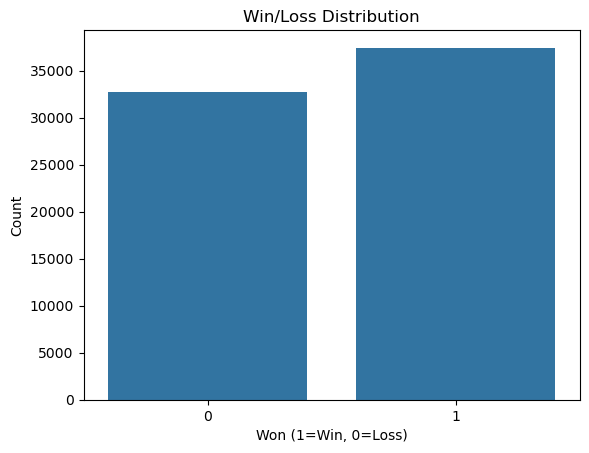

won
1    0.533183
0    0.466817
Name: proportion, dtype: float64

In [8]:
sns.countplot(x="won", data=df)
plt.title("Win/Loss Distribution")
plt.xlabel("Won (1=Win, 0=Loss)")
plt.ylabel("Count")
plt.show()

df["won"].value_counts(normalize=True)

The results show that the dataset is well-balanced, with 53.3% of the recorded games resulting in a win (1) and 46.7% resulting in a loss (0). Because the distribution is nearly 50/50, we do not suffer from a class imbalance problem. This means we can safely proceed to model training without needing to apply synthetic sampling techniques or class weighting. Furthermore, it ensures that baseline evaluation metrics, such as overall accuracy, will be reliable indicators of our models' actual performance.

### 2. What is the Distribution of Player Ratings?

This visualization is a histogram overlaid with a Kernel Density Estimate (KDE) curve and it displays the frequency distribution of player ratings (`rating`) across the dataset, to show the concentration of different skill levels within the games.

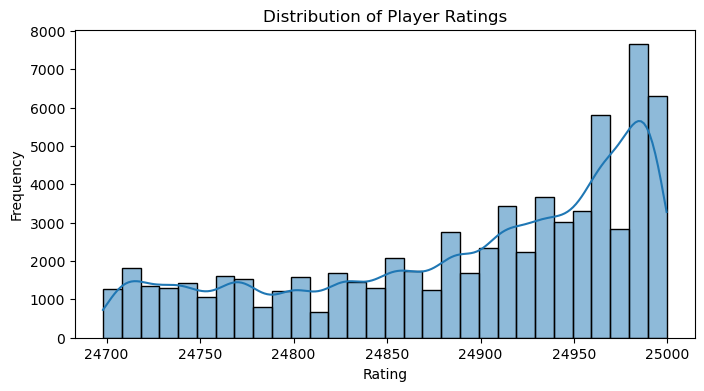

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df["rating"], kde=True, bins=30)
plt.title("Distribution of Player Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

The distribution of player ratings is noticeably skewed left or negatively skewed, which indicates that the bulk of the matches in our dataset are played by individuals clustered at the higher end of the rating spectrum, with a long tail extending toward the lower ratings. Contextually, this makes sense because the dataset specifically focuses on the Top 500 Tetra League players (where the maximum rating is 25,000), the majority of the data represents the elite players crowded near the rating ceiling, while relatively fewer players occupy the "lower" bounds of this top-tier bracket. 

Because the rating distribution is highly compressed, wherein everyone in this dataset is an elite player, rating alone might not be a strong predictor of who wins a match. In a completely random sample of all Tetrio players, a 5000-point rating difference would guarantee a win, but in this Top 500 dataset, a 50-point rating difference might mean nothing. This highlights the importance of our engineered gameplay features (APM, PPS, T-spin rate) to act as the primary deciders for our machine learning models to predict wins.

### 3. What is the Distrbution of Game Lengths in Seconds?

This plot also displays a histogram with a Kernel Density Estimate (KDE) overlay to visualize the overall distribution of game lengths (`duration_sec`) across all recorded matches in the dataset. It helps establish the typical pacing and lifespan of a Top 500 Tetrio match.

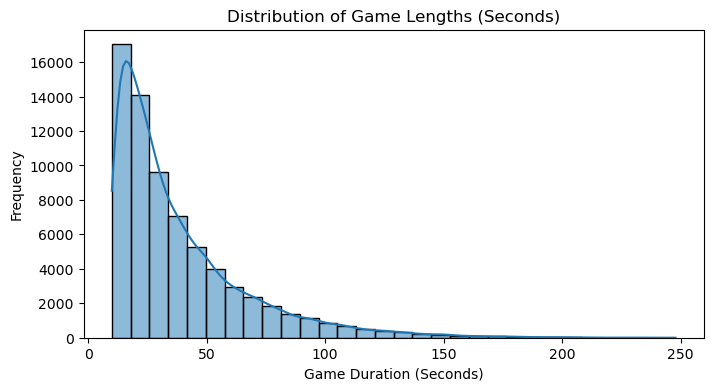

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df["duration_sec"], kde=True, bins=30)
plt.title("Distribution of Game Lengths (Seconds)")
plt.xlabel("Game Duration (Seconds)")
plt.ylabel("Frequency")
plt.show()

The results of the graph indicates that the vast majority of Top 500 Tetrio matches are fast-paced and end relatively quickly as it is clearly right skewed. Considering Tetrio as a fast-paced competitive game and with elite gameplay, players are highly lethal, often securing knockouts in a short timeframe. The long tail extending to the right represents rare "marathon" matches where two players are perfectly matched in defense and attack, dragging the game out significantly longer than average, with the maximum almost reaching 250 seconds (4 minutes).

Because the data is right-skewed, our models must be robust to varying match lengths. A player's raw totals will naturally be much higher in the long-tail games. This visually justifies our preprocessing step of engineering rate-based features (e.g., APM, PPS) instead of using raw sums, ensuring the models evaluate player performance consistently regardless of how quickly the match ended.

### 4. What is the distribution of Pieces Per Second (PPS) and Attack Per Minute (APM)?

This visualizes the underlying distribution of two fundamental gameplay metrics, which is raw speed (Pieces per Second, or PPS) and offensive output (Attack per Minute, or APM). Histograms with Kernel Density Estimate (KDE) curves were used to examine the spread, central tendency, and shape of these features across all games in the dataset.

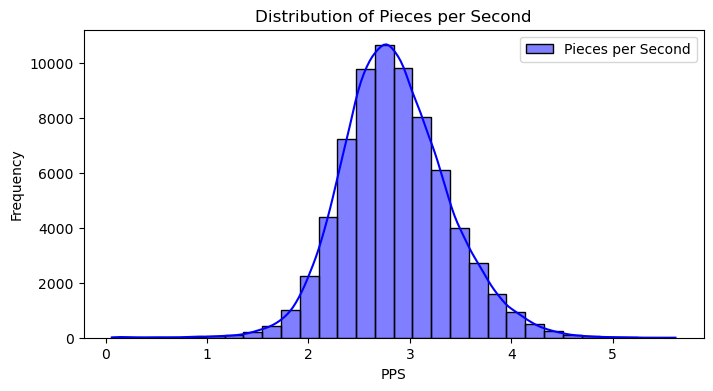

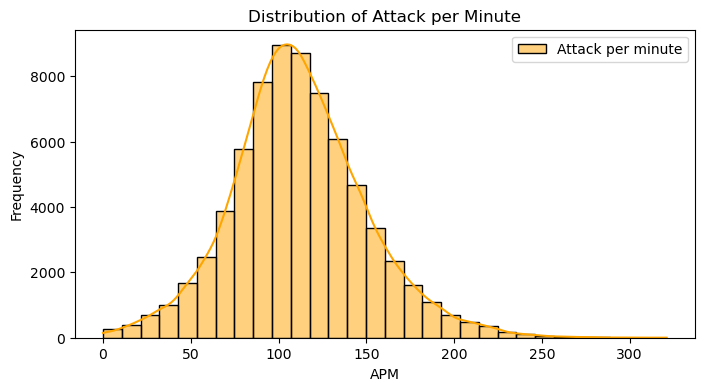

In [35]:
plt.figure(figsize=(8, 4))
sns.histplot(df["pps"], kde=True, color="blue",
             bins=30, label="Pieces per Second")
plt.title("Distribution of Pieces per Second")
plt.xlabel("PPS")
plt.ylabel("Frequency")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    df["apm"], kde=True, color="orange", bins=30, label="Attack per minute"
)
plt.title("Distribution of Attack per Minute")
plt.xlabel("APM")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The distribution of Pieces Per Second (PPS) reveals that the average Top 500 player typically drops around 2.7 pieces per second. The distribution of PPS is also highly symmetric and normally distributed around the center, with a slightly narrow spread. This indicates that at the Top 500 level, most players operate at a very similar, consistent baseline speed, with very few extremely slow or exceptionally fast outliers.

Similarly, the players' Attack Per Minute (APM) clusters around 100 APM. APM also exhibits a roughly normal distribution but is shifted slightly to the left and significantly wider spread, implying that the majority of players consistently output an average amount of damage, but pushing into the extremely high APM ranges is comparatively rarer and more difficult than achieving a high raw drop speed. This also tells us that even though these elite players are dropping pieces at the same speed, the amount of damage they output varies wildly based on their specific playstyle and efficiency.

Because PPS is centrally clustered, raw speed alone may not be the primary differentiator between a win and a loss among elite players. The models will likely prioritize how efficiently that speed is used (APM). The slight left-shift in APM suggests that players who can reach those higher, rarer attack thresholds might have a distinct, easily learned advantage.

### 5. How does average Attack Per Minute (APM) differ between winning games and losing games?

The provided exploratory data analysis (EDA) utilizes a boxplot to compare the distribution of a player's Attack Per Minute (APM) against the binary target variable, match outcome (Win vs. Loss). This visualization effectively contrasts the central tendency, interquartile spread, and extreme outlier behaviors of offensive output between winning and losing games.

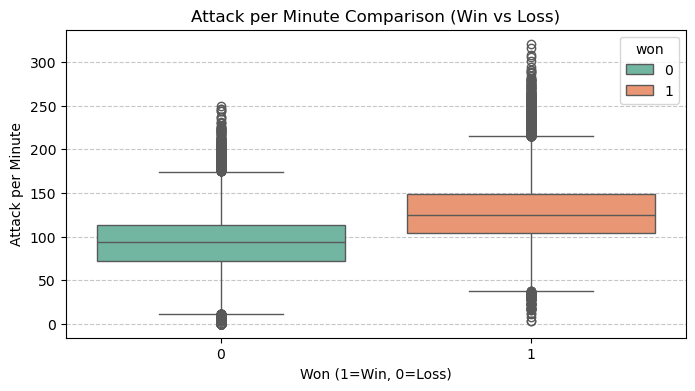

       count        mean        std       min         25%         50%  \
won                                                                     
0    32792.0   92.878400  33.093707  0.000000   72.394503   93.275076   
1    37454.0  128.271315  34.911283  2.956879  104.081684  124.247370   

            75%         max  
won                          
0    113.203440  249.566724  
1    148.330176  321.039750  


In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    x="won",
    y="apm",
    data=df,
    hue="won",
    palette="Set2",
    dodge=False,
)
plt.title("Attack per Minute Comparison (Win vs Loss)")
plt.xlabel("Won (1=Win, 0=Loss)")
plt.ylabel("Attack per Minute")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print(df.groupby("won")["apm"].describe())

Looking at the boxplot, winning games exhibit a visibly higher median Attack per Minute (roughly 125 APM) compared to losing games (roughly 95 APM). This upward shift is also reflected in the entire interquartile range, where the 75th percentile for losses sits below the median for wins, indicating a positive correlation between higher APM and winning. 

While both groups display a significant number of high-value outliers, the absolute highest APM values, which approach and exceed 300, are predominantly found among the winners. However, despite this overall upward shift for winners, there is still substantial overlap between the two distributions. For instance, a player with an APM of 110 could reasonably belong to either a winning or a losing game.

Because the distributions are distinctly different, `APM` will serve as a highly valuable predictive feature that our models will rely on to calculate win probabilities. Yet, due to the substantial overlap between the distributions, APM alone is not enough and a simple threshold rule would result in many false positives and false negatives. Finally, the presence of extreme APM outliers indicates that linear models may require the APM to be scaled as to not disproportionately skew the model's weights.

### 6. Do winning games exhibit a higher average Attack Efficiency (garbage sent per piece) than losing games?

This investigates the relationship between a player's attack efficiency and the outcome of the match. It uses boxplot to visually contrast the distribution of the `attack_per_piece` feature between winning (1) and losing (0) games. Additionally, it outputs a numerical summary table using the describe() function, providing exact statistical measures—such as the mean, median, standard deviation, and quartiles—for both groups to support the visual findings.

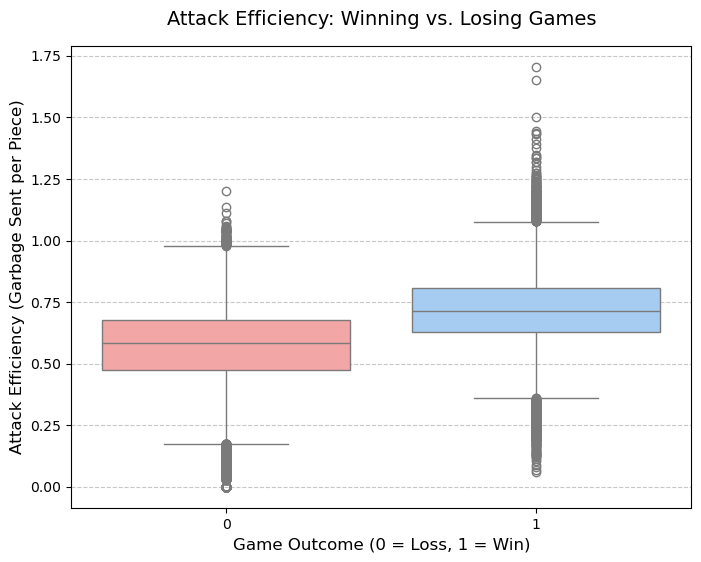

       count      mean       std       min       25%       50%       75%  \
won                                                                        
0    32792.0  0.566540  0.164676  0.000000  0.475560  0.584746  0.676471   
1    37454.0  0.717233  0.142973  0.058824  0.628099  0.715190  0.807692   

          max  
won            
0    1.200000  
1    1.705882  


In [13]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="won",
    y="attack_per_piece",
    hue="won",
    data=df,
    palette=["#FF9999", "#99CCFF"],
    legend=False
)

plt.title("Attack Efficiency: Winning vs. Losing Games", fontsize=14, pad=15)
plt.xlabel("Game Outcome (0 = Loss, 1 = Win)", fontsize=12)
plt.ylabel("Attack Efficiency (Garbage Sent per Piece)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print(df.groupby("won")["attack_per_piece"].describe())

Based on the visual boxplot, winners are significantly more efficient, with the median attack efficiency for winning games at 0.715, substantially higher than the 0.585 median for losing games. The means from the table reflect this same gap at 0.717 versus 0.566. 

There is also a clear distribution shift heavily upward for the victors as the interquartile range for wins sits between 0.628 and 0.808. Notably, the 25th percentile for winning games (0.628) is almost as high as the 75th percentile for losing games (0.676), meaning the bottom 25% of winners are roughly as efficient as the top 25% of losers. 

Furthermore, the tighter variance in winning games suggests that maintaining consistently high efficiency is a strict requirement for winning at a high level, whereas losing games exhibit a wider, more erratic spread. 

Finally, while both groups contain extreme high-end outliers, the maximum efficiency observed in a winning game (1.706) far exceeds the maximum in a losing game (1.200).

Because the distributions are distinctly separated with minimal IQR overlap, `attack_per_piece` emerges as a strong predictive feature, meaning that the models will likely assign a high weight or importance to this variable. However, despite the clear upward shift for winners, an overlap still exists in the middle of the distributions. For example, an efficiency rating of 0.65 could reasonably belong to either a win or a loss. Therefore, a model cannot rely on this feature alone and will need to cross-reference it with the other engineered metric to accurately resolve those overlapping edge cases.

### 7. How does the T-Spin Rate differ between games that were won versus games that were lost?

This investigates the relationship between a player's T-Spin rate (T-Spins executed per piece placed) and the final match outcome. The analysis pairs a visual boxplot with summary statistics to determine if high-level players rely on T-Spins to secure victories, or if alternative playstyles are equally viable.

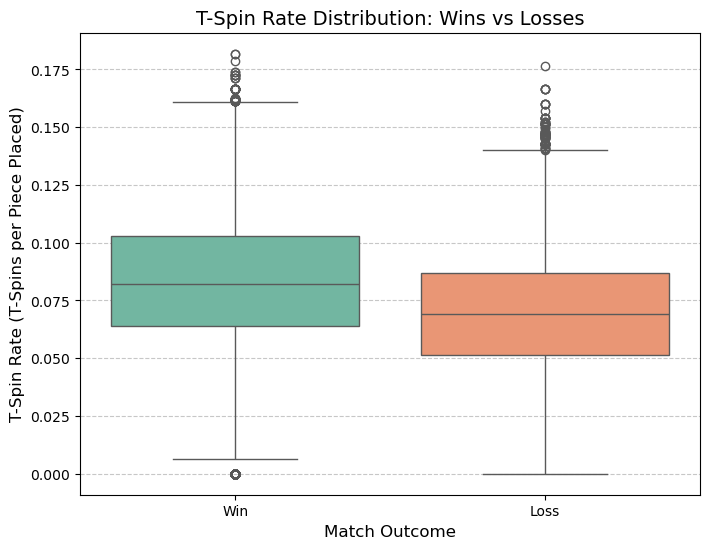

       count      mean       std  min       25%       50%       75%       max
won                                                                          
0    32792.0  0.068869  0.027943  0.0  0.051429  0.068966  0.086957  0.176471
1    37454.0  0.084047  0.028926  0.0  0.064103  0.082305  0.102941  0.181818


In [14]:
df['won_category'] = df['won'].map({0: 'Loss', 1: 'Win'})

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="won_category",
    y="tspin_rate",
    data=df,
    palette="Set2",
    hue="won_category",
    legend=False
)

plt.title("T-Spin Rate Distribution: Wins vs Losses", fontsize=14)
plt.xlabel("Match Outcome", fontsize=12)
plt.ylabel("T-Spin Rate (T-Spins per Piece Placed)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

df.drop(columns=['won_category'], inplace=True)

print(df.groupby("won")["tspin_rate"].describe())

Based on the visual distribution with the descriptive table, the median T-Spin rate in winning games (0.082) is notably higher than in losing games (0.069). On average, players who win are setting up and executing T-Spins more consistently throughout the match. 

Furthermore, The entire interquartile range is shifted upward for wins, specifically the 25th percentile for a winning game (0.064) is only slightly below the median for a losing game (0.069), meaning a "below average" winning player still T-Spins nearly as much as an "average" losing player. 

Unlike some statistics where losing games might be highly erratic, the standard deviation is remarkably similar for both wins (0.029) and losses (0.028). 

Finally, both groups have a minimum value of 0.0, indicating that it is entirely possible to win a high-level game without performing a single T-Spin, though the bulk of the data shows this is the exception rather than the rule.

Because there is a measurable upward shift in the T-spin rate for winning games, `tspin_rate` will serve as a highly valuable, discriminative feature for our models. Combined with other features, it could likely find a strong predictive power. However, because players can win with a 0 `tspin_rate`, a model will need other features to correctly classify winning games from players who use non-T-spin heavy strategies.

### 8. How does the average pressure faced (Incoming Garbage queue) compare between winning and losing games?


This analyzes the defensive pressure players face during a match by analyzing the "incoming garbage" metric. Two side-by-side boxplots accompanied by summary statistics are used to compare the distribution of Average Pressure (`incoming_garbage_mean`) and Peak Pressure (`incoming_garbage_max`) between players who lost (0) and players who won (1).

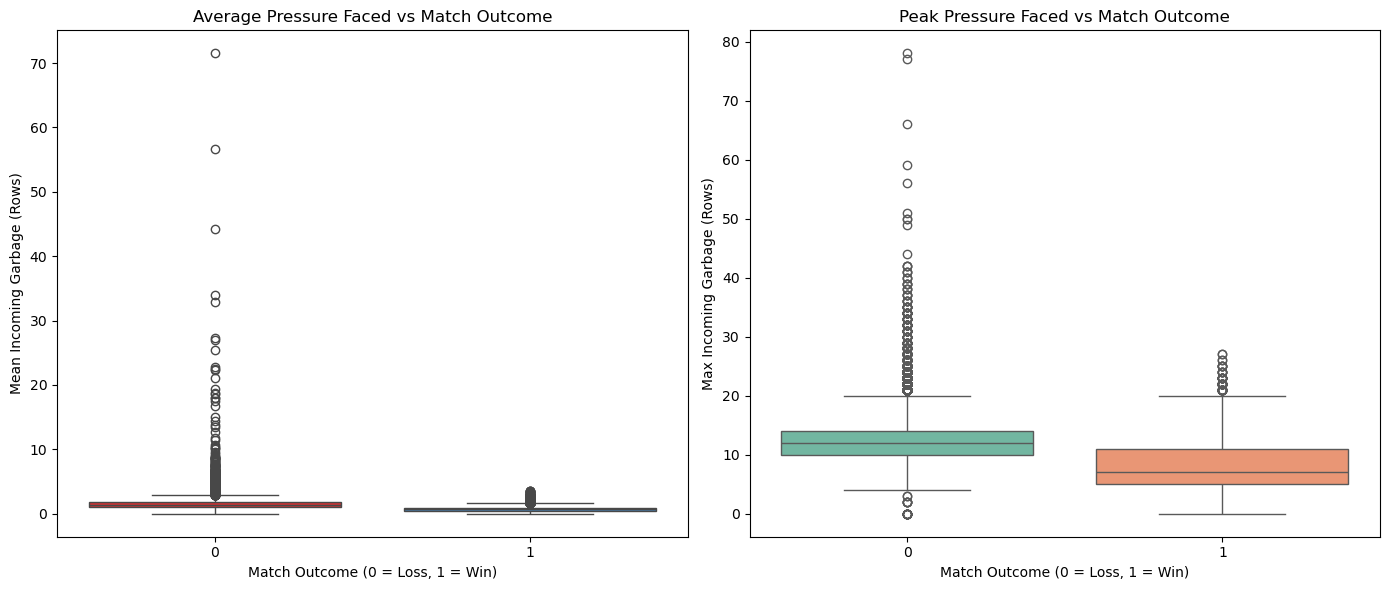

Average Pressure Faced vs Match Outcome
       count      mean       std  min       25%       50%       75%        max
won                                                                           
0    32792.0  1.545759  1.073505  0.0  1.031097  1.350971  1.806868  71.500000
1    37454.0  0.681645  0.394302  0.0  0.408537  0.658537  0.915663   3.574074

Peak Pressure Faced vs Match Outcome
       count       mean       std  min   25%   50%   75%   max
won                                                           
0    32792.0  12.013784  4.093811  0.0  10.0  12.0  14.0  78.0
1    37454.0   8.015753  3.796518  0.0   5.0   7.0  11.0  27.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df,
    x="won",
    y="incoming_garbage_mean",
    hue="won",
    ax=axes[0],
    palette="Set1",
    legend=False
)
axes[0].set_title("Average Pressure Faced vs Match Outcome")
axes[0].set_xlabel("Match Outcome (0 = Loss, 1 = Win)")
axes[0].set_ylabel("Mean Incoming Garbage (Rows)")

sns.boxplot(
    data=df,
    x="won",
    y="incoming_garbage_max",
    hue="won",
    ax=axes[1],
    palette="Set2",
    legend=False
)
axes[1].set_title("Peak Pressure Faced vs Match Outcome")
axes[1].set_xlabel("Match Outcome (0 = Loss, 1 = Win)")
axes[1].set_ylabel("Max Incoming Garbage (Rows)")

plt.tight_layout()

plt.show()

print("Average Pressure Faced vs Match Outcome")
print(df.groupby("won")["incoming_garbage_mean"].describe())
print("\nPeak Pressure Faced vs Match Outcome")
print(df.groupby("won")["incoming_garbage_max"].describe())

The plots and statistics tell us that across both average and peak metrics, winning games feature much lower incoming garbage. The median average pressure for a win is just 0.658 rows, compared to 1.351 rows for a loss. 

The `incoming_garbage_max` plot also shows that losing games involve absorbing massive spikes of garbage. The median peak for a loss is 12 rows, which fills more than half the board, while winners typically only face a peak of 7 rows. 

Perhaps the most notable visual element is the presence of extreme outliers in the losing category. For average incoming garbage, one losing game reached a massive 71.5 rows, while the absolute highest average for a winning game was only 3.57. Similarly, peak garbage hit a staggering 78 rows in a losing game, compared to a max of 27 for a win. This indicates that many losses are "blowouts" where the player is completely overwhelmed. 

Additionally, since these are high-level matches, the low incoming garbage for winners likely doesn't mean their opponents weren't attacking. Instead, it implies the winning players were highly efficient at canceling incoming attacks with their own offensive output before the garbage could materialize on their board.

These findings confirm that `incoming_garbage_mean` and `incoming_garbage_max` are highly predictive features. Because there is a clear, quantifiable separation in their distributions wherein winners consistently have lower values with less variance, our models will surely rely on them. Furthermore, these features will have a negative correlation with the probability of winning and the model will use high incoming garbage values as an indicator of a likely loss. However, with the extreme outliers in the losing category, transformation should be applied to not distort a model's weights.

### 9. Is there a linear relationship between a player's raw speed (PPS) and their damage output (APM)?

This investigates the linear relationship between a player's raw physical speed (Pieces Per Second or `PPS`) and their offensive damage output (Attack Per Minute or `APM`). A scatter plot with a linear regression trendline was used, and the Pearson correlation coefficient was calculated to formally quantify the strength and direction of this relationship.

Pearson Correlation Coefficient (r): 0.672
P-value: 0.000e+00


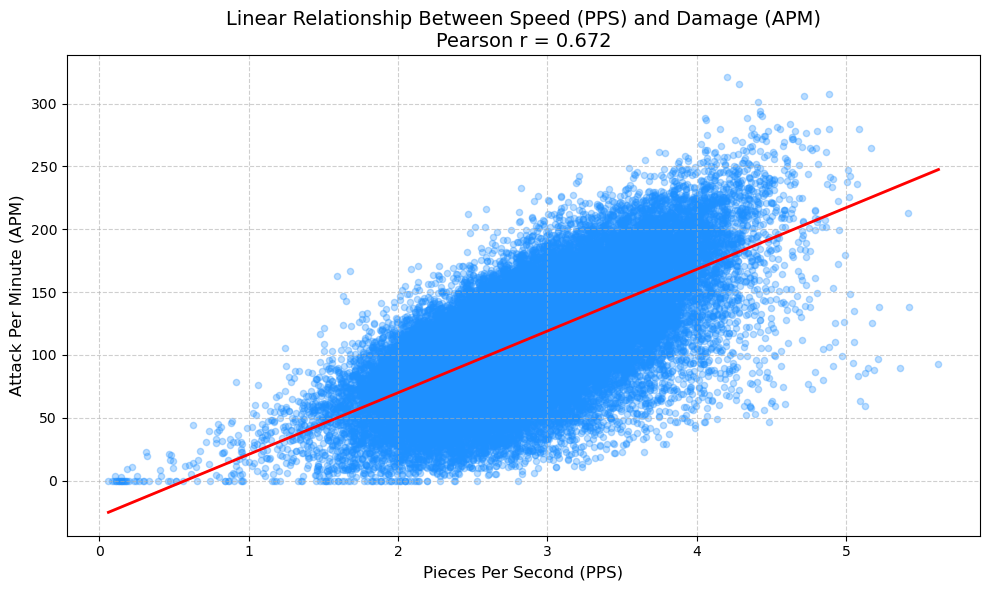

In [16]:
corr, p_value = pearsonr(df['pps'], df['apm'])
print(f"Pearson Correlation Coefficient (r): {corr:.3f}")
print(f"P-value: {p_value:.3e}")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='pps',
    y='apm',
    scatter_kws={'alpha': 0.3, 'color': 'dodgerblue', 's': 20},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title(f"Linear Relationship Between Speed (PPS) and Damage (APM)\nPearson r = {
          corr:.3f}", fontsize=14)
plt.xlabel("Pieces Per Second (PPS)", fontsize=12)
plt.ylabel("Attack Per Minute (APM)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The plot clearly and correlation coefficient value clearly indicates a strong, positive linear relationship between speed and damage. As expected, players who drop pieces faster generally send more garbage lines to their opponents. With the p-value practically being zero, this correlation is statistically significant and definitely not due to random chance within the dataset.

While the correlation is strong, it is not a perfect 1.0. The variance around the trendline means there are distinct playstyles where some players achieve high APM despite a lower PPS, possibly indicating highly efficient, deliberate setups like T-Spins, while others might have a massive PPS but lower than expected APM possibly indicating inefficient "button mashing" or survival-focused play.

Because `pps` and `apm` are strongly correlated, they share overlapping information. In a logistic regression model, this multicollinearity might make the individual feature coefficients slightly harder to interpret, as the model may arbitrarily distribute the "weight" of importance between the two. Also, the fact that they are not perfectly correlated suggests the need for complex models to look at the intersection of these two features.

### 10. Does relying heavily on maximum combo chains correlate with higher Back-to-Back (B2B) chains?

This uses a multivariate scatterplot with an overlaid linear regression trendline to maps two specific advanced gameplay mechanics against each other, which is `combo_max` (the highest consecutive sequence of any line clears) and `btb_max` (the highest consecutive sequence of "difficult" line clears, like Tetrises and T-Spins).

Pearson Correlation between Max Combo and Max B2B: -0.0088


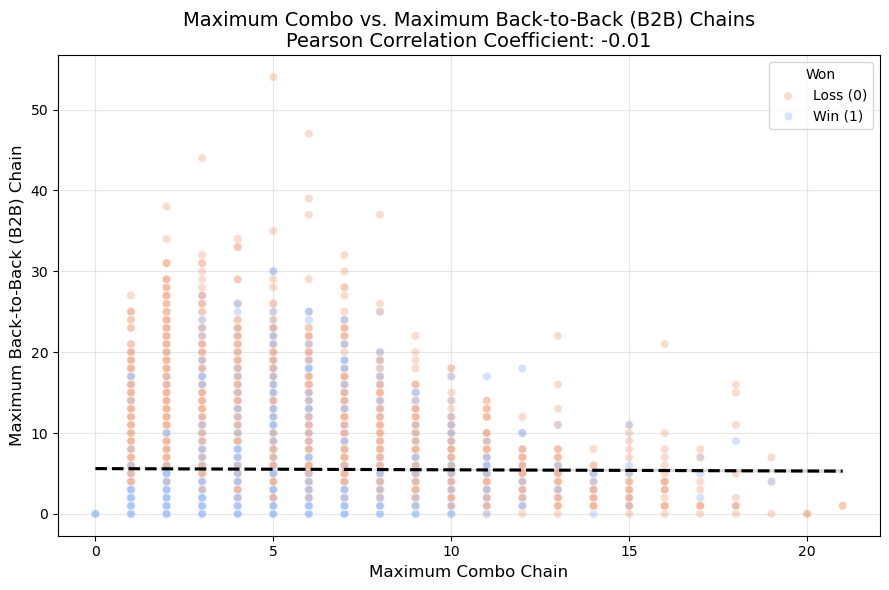

In [17]:
correlation = df["combo_max"].corr(df["btb_max"])
print(f"Pearson Correlation between Max Combo and Max B2B: {correlation:.4f}")

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="combo_max",
    y="btb_max",
    hue="won",
    alpha=0.5,
    palette="coolwarm"
)

sns.regplot(
    data=df,
    x="combo_max",
    y="btb_max",
    scatter=False,
    color='black',
    line_kws={"linestyle": "--"}
)

plt.title(f"Maximum Combo vs. Maximum Back-to-Back (B2B) Chains\nPearson Correlation Coefficient: {
          correlation:.2f}", fontsize=14)
plt.xlabel("Maximum Combo Chain", fontsize=12)
plt.ylabel("Maximum Back-to-Back (B2B) Chain", fontsize=12)
plt.legend(title="Won", labels=["Loss (0)", "Win (1)"])
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

This plot shows that an absolutely zero linear relationship exists between a player's maximum combo and their maximum B2B chain as the correlation coefficient is -0.01 and is accompanied by the flat black dashed trendline.

This makes sense because to maintain a high "combo" (clearing lines back-to-back-to-back with any piece), you usually have to break your "B2B" chain (which requires only Tetrises or T-Spins). Players generally commit to one offensive style or the other at any given moment.

Looking at the extreme ends of both axes, the highest B2B chains (above 30) and the highest Combo chains (above 15) are almost exclusively losses. This is because building a massive, singular chain requires a highly specific board state and taking significant risks. Players who focus on building one gigantic chain are likely ignoring defense, failing to downstack opponent garbage, and ultimately topping out before or shortly after they execute it.

Meanwhile, wins are heavily concentrated in the lower-to-mid ranges of both axes as consistent, moderate attacks are much more indicative of a winning game than a single massive spike.

Because the correlation is effectively zero, multicollinearity between these two features will not be an issue. A model will use these features to understand how a player attacks. For instance, if `combo_max` is high and `btb_max` is low, the model recognizes a "combo-heavy" playstyle, and vice versa. However, non-linear decision boundaries are still required to account for the fact that extreme strategies usually result in a loss

### 11. When plotting Speed (PPS) against Attack (APM), do winning games cluster in a specific region compared to losing games?

This bivariate scatterplot visualizes and investigates the relationship between a player's raw placement speed (Piece per Second or `PPS`) and their offensive damage output (Attack per Minute or `APM`).

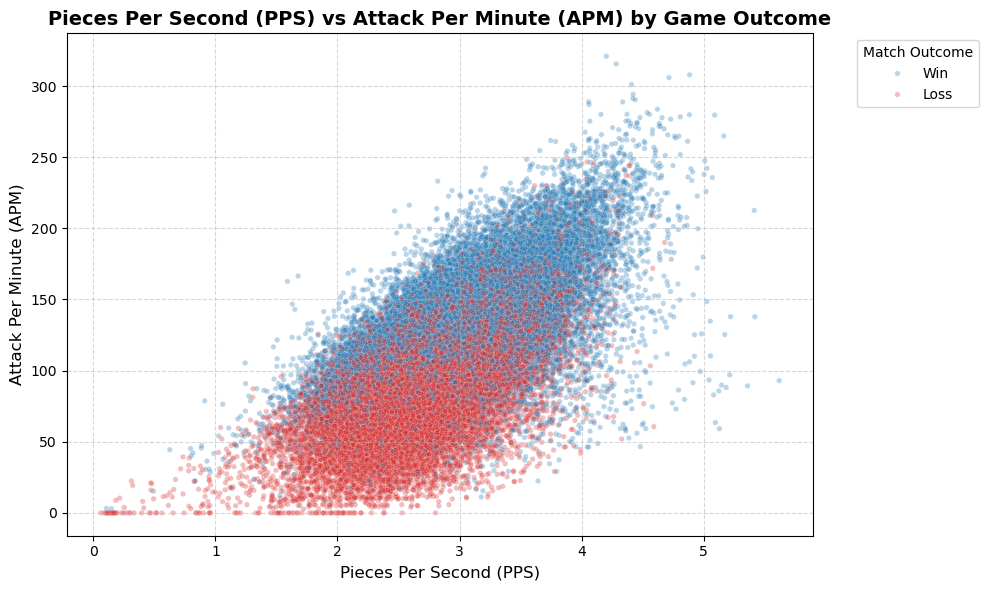

In [18]:
df['Outcome'] = df['won'].map({1: 'Win', 0: 'Loss'})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='pps',
    y='apm',
    hue='Outcome',
    palette={'Win': '#1f77b4', 'Loss': '#d62728'},
    alpha=0.3,
    s=15
)

plt.title('Pieces Per Second (PPS) vs Attack Per Minute (APM) by Game Outcome',
          fontsize=14, fontweight='bold')
plt.xlabel('Pieces Per Second (PPS)', fontsize=12)
plt.ylabel('Attack Per Minute (APM)', fontsize=12)

plt.legend(title='Match Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

df.drop(columns=['Outcome'], inplace=True)

The plot shows that while both wins and losses follow the general upward trend where faster speed = more attacks, the blue "Win" points is distinctly shifted upward compared to the red "Loss" points.

However, speed does not guarantee victory as there are a lot of overlapping points, suggesting that the quality and efficiency of piece placement or generating attacks may be the true differentiator.

We can also see that a at the bottom edge of the distribution, where players are playing fast but generating almost 0 APM, is almost entirely red (loss). These are players who are just dropping pieces to survive or misdropping heavily without completing offensive line clears. Meanwhile, the extreme upper edge of the points is almost exclusively blue, regardless of the PPS required to get there, indicating that a high APM is a near-guarantee win condition.

This visualization clearly shows that a model will require complex decision boundaries to separate the blue and red clusters accurately. This also tells us that having an `attack_per_piece` is an essential variable as it would serve a slope of these points, simplifying the decision boundary. 

---

## Model Selection

To carry out the prediction task this study used 2 classical machine learning models and 1 neural network model, specifically:

- #### k-Nearest Neighbors
- #### Logistic Regression
- #### Neural Network with a Sigmoid Activation

### Justification for Model Selection

Since our goal is a binary classification (predicting a win or loss), our chosen models are appropriate for that particular task with the proper setup and implementation.

**k-Nearest Neighbors (KNN)** is a non-parametric, distance-based algorithm. It doesn't use an equation and instead looks at a new game, finds the 'k' most statistically similar games in the training data, and predicts the majority outcome of those neighbors. In the context of our data, it can serve as a playstyle clusterer since the exploratory data analysis shows that Tetrio has distinct playstyles at the Top 500 level. kNN was chosen because it can naturally identify these non-linear "clusters." If a player has low PPS but insanely high attack efficiency, kNN will match them with similar historical games to predict their win condition, bypassing rigid linear assumptions.

**Logistic Regression** is a standard for binary classification tasks as it calculates the log-odds of an event happening based on a linear combination of features. It is also a model that not only predicts wins but explains them since it provides coefficients for every feature making it interpretable. For instance, this allows us to say exactly how much a 1-unit increase in APM or PPS increases a player's probability of winning as it assumes a straightforward relationship wherein "more efficient stats = higher chance to win."

**Neural Network** or specifically a multi-layer perceptron learns hidden, complex, and deeply non-linear interactions between variables that classical models may miss, especially since it has been observed in the exploratory data analysis that Tetrio is a game of complex, overlapping variables. For instance, a high APM might only lead to a win if the player's defensive garbage clearing is also above a certain threshold. With an appropriate activation function, optimizer, and configuration of hidden layers, it can excel at learning these complex conditional relationships. Given the that we are predicting a binary outcome, using a sigmoid activation in the output layer is a must.

For **rejecting the alternatives**, linear regression is simply designed for predicting continuous values; Naive Bayes assumes that all features are conditionally independent of each other, when in fact it is not, as observed from the exploratory data analysis where variables can be correlated. Thus, Naive Bayes' would likely suffer from degraded accuracy; While a single decision tree is highly interpretable, it is prone to overfitting, especially on datasets with continuous numerical rates. A single tree will create harsh, jagged, and highly specific cutoffs that memorize the training data but fail to generalize to the test set; Support Vector Machines, on the other hand, are incredibly powerful but scale poorly with large datasets. Given the amount of data we are dealing with, we thought that using it would be computationally expensive and painfully slow to train and tune during the validation phase, probably offering little benefit over the much faster Neural Network.

With that, we also considered our computational limitations when choosing the models and configuring them.

## K-Nearest Neighbor

---

### Initialization and Data Prep

Before training a distance-based model like kNN, data consistency and scaling are paramount. We begin by importing the necessary analytical and visualization suites.

#### Imports and Initializations

We utilize `sklearn` for the core model logic and evaluation metrics. `seaborn` and `matplotlib` are used to visualize the "elbow" of the hyperparameter tuning curve and the final confusion matrix.

#### Target Separation and Normalization

kNN is highly sensitive to the scale of features because it calculates the
Euclidean distance between data points. If one feature (like `rating`) has a
much larger range than another (like `pps`), it will dominate the distance calculation.

We do not standardize the dataset yet, to avoid data leakage from training and test set.

In [ ]:
# Target separation
X = df.drop(columns=["won"])  # Features
y = df["won"]  # Target variable

#### Data Split

We split the dataset into training and testing sets to evaluate how well the
model generalizes to unseen replays. A 85%/15% split is utilized here, where
85% of the training data is validated automatically by a single fold created
by `cross_val_score`, and tested on the remaining 15%.

In [ ]:
# Split data into training and test sets
# Stratification ensures win/loss proportions are maintained
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

print(f"Training data: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Testing data: {X_test.shape}")
print(f"Testing labels: {y_test.shape}")

Training data: (65188, 16)
Training labels: (65188,)
Testing data: (11504, 16)
Testing labels: (11504,)


#### Pipeline and Model Instantiation

We instantiate a `Pipeline()` that sets the machine learning pipeline where
the dataset is first standardized and used to train the model. This ensures that
standardization happens within its own sets.

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

### Model Training

We begin by training a "pilot" model with a default value of _k=5_. This
allows us to establish a baseline performance before beginning the search for
the optimal neighborhood size. The model training is almost instantaneous due to
the nature of kNN's training pipeline.

In [ ]:
# Train initial kNN model
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30


#### Initial Model Performance

We can then test the current performance of the model with the set hyperparameter
of _k_ =5.

In [ ]:
# Initial Predictions
y_pred = pipeline.predict(X_test)
print(f"Baseline Accuracy (k=5): {accuracy_score(y_test, y_pred):.2f}")

# Store probability for later use
probs_k5 = pipeline.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.6f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Baseline Accuracy (k=5): 0.85
Accuracy: 0.852573

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      5353
           1       0.85      0.87      0.86      6151

    accuracy                           0.85     11504
   macro avg       0.85      0.85      0.85     11504
weighted avg       0.85      0.85      0.85     11504



Our initial model shows an **accuracy of 0.862573**. This is a relatively high accuracy, which nears 0.9. Let's see if we can increase that further by tuning the hyperparameter later on.

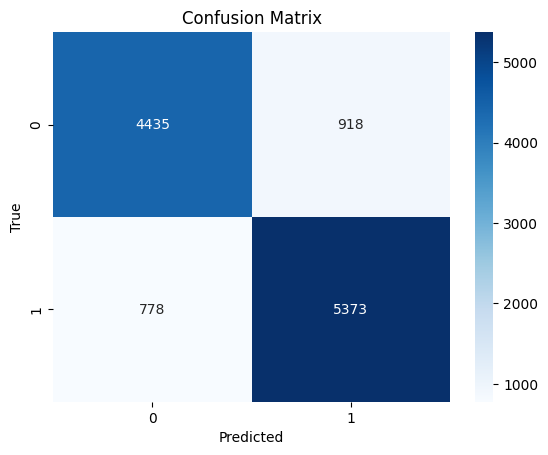

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Shown in the confusion matrix are the quantifiable data of the initial model's performance. The false positives and negatives are summed up to 1696, which are the total errors produced by the model.

### Hyperparameter Tuning

Next is to explore the ideal hyperparameter that yields the highest accuracy
or least loss. A small _k_ such as 5 can lead to overfitting, while a high _k_
may lead to underfitting. Thus, there must be a right hyperparameter for this model.

#### Identifying the best _k_

We set a reasonable range for the hyperparameter tuning, which is from 1-31. The
typical range is up to 21, but to consider the dataset and to visualize the curve
better, we add an extra 10. We also only use odd hyperparameters to avoid ties. We also implement `weights='distance'` to ensure that closer neighbors have a higher influence on the classification, mitigating the noise often found in competitive gaming data.

In [ ]:
# Set a hyperparameter range from 1-31
k_values = range(1, 51, 2)
cv_scores = []

# Iterate through the range to test for accuracy
for k in k_values:
    # Update pipeline k
    pipeline.set_params(knn__n_neighbors=k, knn__weights='distance')
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

With the hyperparameter tuned, we can visualize the the accuracy of the all the hyperparameters.

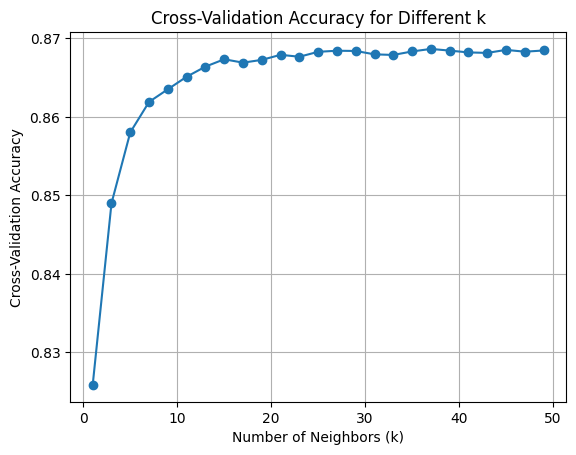

In [ ]:
# Cross validation accuracy
plt.plot(k_values, cv_scores, marker="o")
plt.title("Cross-Validation Accuracy for Different k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validation Accuracy")
plt.grid(True)
plt.show()

There is a sharp increase in accuracy in ranges of 1 to 10 for k, and a slower increase from 10 to 20. When **_k_ is 20 and above, the accuracy flattens**. The best _k_ can be found from _k_ = 20 and up. We will let the pipeline select the ideal _k_ based on the highest cross-validation accuracy.

### Best k Results

In [ ]:
# Best k selection
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k} with Cross-Validation Accuracy: {max(cv_scores):.6f}")

Best k: 37 with Cross-Validation Accuracy: 0.868657


The cross-validation process identified _k_ = 37 as the optimal neighborhood size with an accuracy of 0.868657. Interestingly, this is nearly identical to our baseline performance at _k_ = 5 (0.852573). We should further explore the confidence of the model in terms of its predictions through a probability distribution.

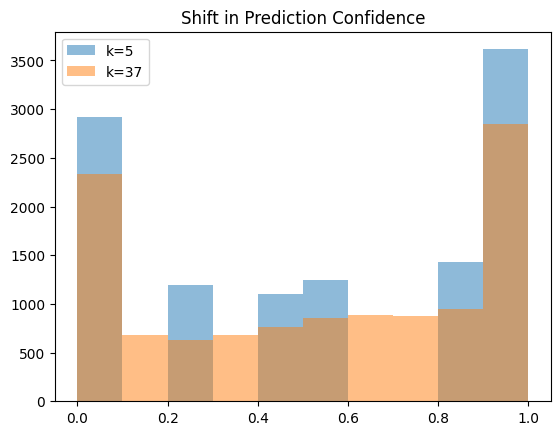

In [ ]:
# Compare probability distributions
probs_k37 = pipeline.predict_proba(X_test)[:, 1]

plt.hist(probs_k5, alpha=0.5, label='k=5')
plt.hist(probs_k37, alpha=0.5, label='k=37')
plt.legend()
plt.title("Shift in Prediction Confidence")
plt.show()

As we can see, the **orange distribution (_k_ = 37) showed a more stable distribution of probability than the blue one (_k_ = 5)**. Despite _k_ = 5 producing higher probabilities of 0 or 1, it fails to have stability in its decision making, hence gaps from 0 to 0.2, 0.3 to 0.4, and 0.6 to 0.8. This is why _k_ = 37 is much more ideal for a more confident prediction. 

We also previously set `knn__weights='distance` which allows the model to prioritize the closest neighbors to influence the probability. Increasing the _k_ consults more neighbors and clarifies the decision better, providing lesser noise and sensitivity to outliers.

#### Decision Boundary

We can also plot a decision boundary for _k_ = 5 and _k_ = 37 to clearly see the confidence of the decision.  

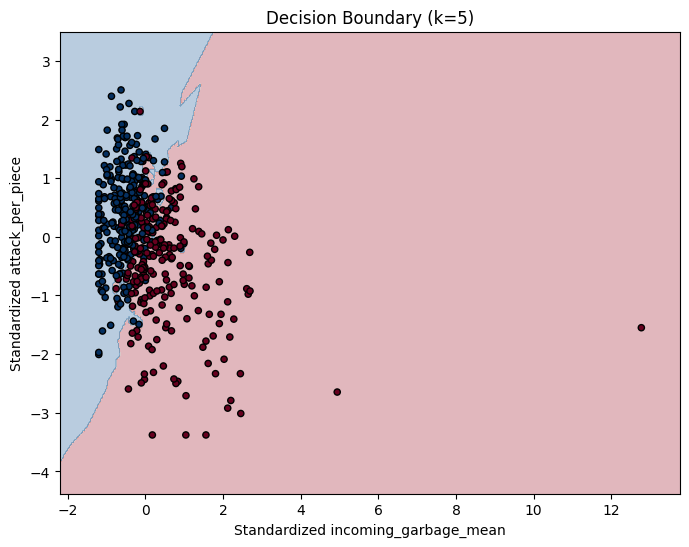

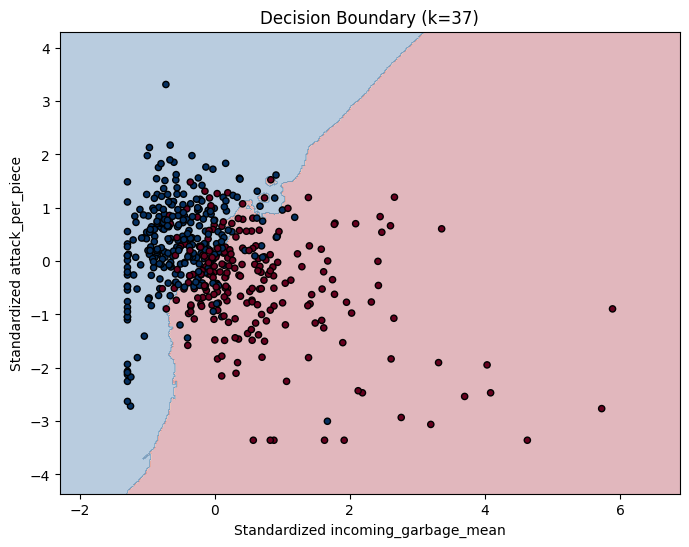

In [ ]:
plot_knn_boundary(5, 'distance', "Decision Boundary (k=5)", X_train, y_train)
plot_knn_boundary(37, 'distance', "Decision Boundary (k=37)", X_train, y_train)

The decision boundary further supports our claim that **_k_ = 37 is more stable and confident than _k_ = 5**. They both have nearly identical accuracy results, but the decision boundary (or line) in _k_ = 37 is smoother than the latter. 

#### Retraining the model

Now that the best _k_ is identified, we can retrain the model using that _k_ to
clearly visualize its performance.

In [ ]:
# Model retraining using best k
pipeline.set_params(knn__n_neighbors=best_k, knn__weights='distance')
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",37
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",3

### Calculate Permutation Importance

Since kNN is a lazy learner and does not have feature importance scores, we use
permutation feature importance (pfi) to identify the top contributors to the model's
decision-making.

In [ ]:
# We use the test set to see how important features are for generalization
result = permutation_importance(
    pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Organize the data for visualization
feature_names = X.columns
importances_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(by="importance_mean", ascending=False)

### Final Model Results

Final Model Accuracy (k=37): 0.869611

Final Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      5353
           1       0.86      0.90      0.88      6151

    accuracy                           0.87     11504
   macro avg       0.87      0.87      0.87     11504
weighted avg       0.87      0.87      0.87     11504



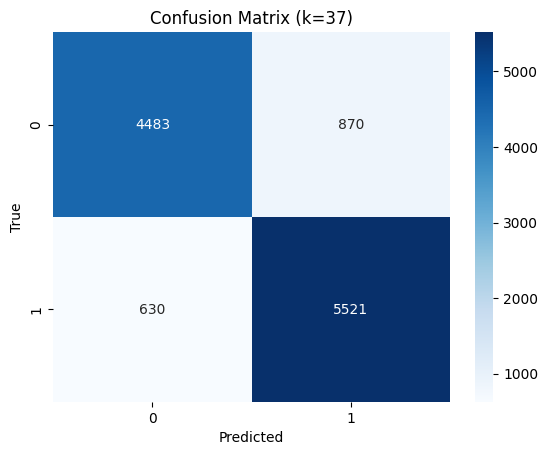

In [ ]:
# Final model evaluation
final_y_pred = pipeline.predict(X_test)
final_accuracy = accuracy_score(y_test, final_y_pred)

print(f"Final Model Accuracy (k={best_k}): {final_accuracy:.6f}")
print("\nFinal Classification Report:\n")
print(classification_report(y_test, final_y_pred))

# Confusion matrix for final model
final_conf_matrix = confusion_matrix(y_test, final_y_pred)
sns.heatmap(final_conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.title(f"Confusion Matrix (k={best_k})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

The final model shows a **high predictive accuracy/f1-score (87%)**. It also has a high recall (0.90) for winning replays, showing a strong distinction for winning playstyles. 

#### Feature Weights

We also want to discover what features influence the model more. We will plot the results of permutation feature importance in a bar plot.

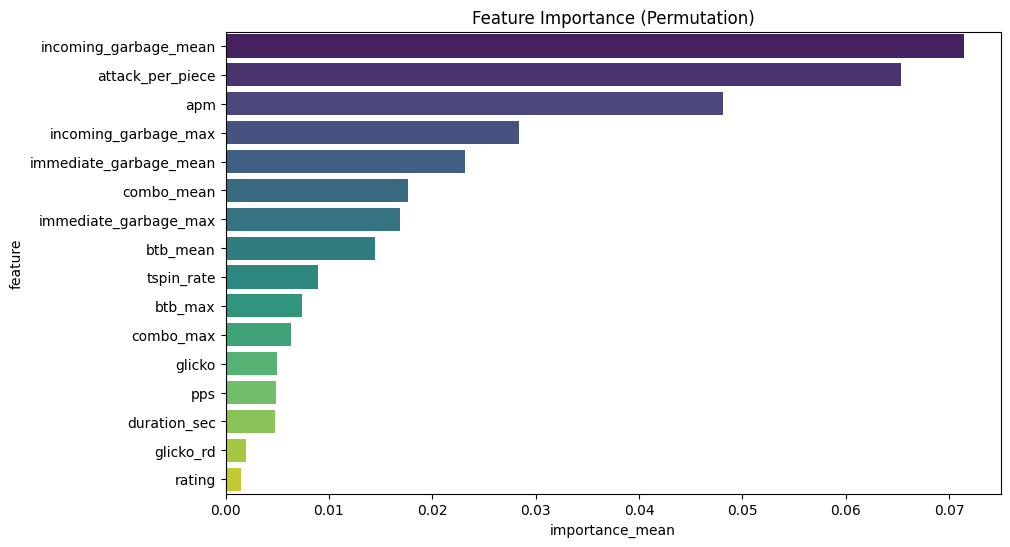

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="importance_mean",
    y="feature",
    data=importances_df,
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance (Permutation)")
plt.show()

From the results, we can infer:
* `incoming_garbage_mean`: **This is the most important feature** that the model utilizes as it has a strong factor to winning/losing. From a Tetrio perspective, we can infer that **incoming garbage is a negative contributor**. As such, we can infer that players who fail to defend themselves against incoming garbage are more likely to lose than consistently attacking.
* `attack_per_piece` & `apm`: **Attack per piece and attacks per minute strongly contribute to winning**. Tetrio dictates attacks as the amount of garbage the player sends to their opponent. In relation to `pps` or pieces per second, having a strong attack with less pieces significantly impacts a match's outcome than speedily placing pieces.
* `btb_mean`, `combo_mean`, and `tspin_rate`: kNN fails to capture if these values are positive or negative contributors. However, this can give us an insight as to what moderately affects a match**.

## Logistic Regression

---

### Initialization and Data Prep

A series of preparations must first be underway before model training. Importing certain libraries for visualizations, metrics, and the like.

#### Imports and Initializations

There are a variety of libraries to work with. `sklearn` is deemed the most significant due to its vast range of machine learning libraries. There are also visualization imports such as `seaborn` and `matplotlib`. `comet_ml` was also utilized for tracking the model's metrics during training.

#### Target separation

Explicitly separate features and target variable for clarity. There is also
no further need to split the data due to the use of `standardscaler`.

In [ ]:
# target separation
X = df.drop(columns=["won"])  # features
y = df["won"]  # target variable

#### Data split

Split the data into training and testing sets.

The data split will be **85%/15%** for this section due to `RandomizedSearchCV`
automated validation split. The mentioned library function is capable of
automatically splitting the fed data into 15%. Therefore, further splitting the
data here will lead to 15% loss in the data due to excess splits.

In [ ]:
# Split data into training and validation
# 85% / 15% split
# RandomizedSearchCV will automatically do a 15% split for validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Check sizes of splits
print(f"Training data: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Testing data: {X_test.shape}")
print(f"Testing labels: {y_test.shape}")

Training data: (65188, 16)
Training labels: (65188,)
Testing data: (11504, 16)
Testing labels: (11504,)


### Model Training

The logistic regression model will be trained via 70% of the dataset.

Training the logistic regression model composed of 2 phases:

- **Phase 1**: Identify optimal epoch through an initial training using a fixed
  learning rate of 0.001 and at a maximum of 150 epochs with a batch size of 64.
  Plotting the loss curve helps identify where the loss flattens.
- **Phase 2**: Tune hyperparameters through 50 iterations using mini-batch
  stochastic gradient descent. Parameters will be tuned using
  `RandomizedSearchCV` from fixed batch sizes of 32, 64, and 128 and a
  learning rate range of 0.0001 to 0.1.

Finding the optimal epoch first allows for resource conservation. In addition to
that, the pipeline uses mini-batch SGD for better computational advantage.

#### Determine Optimal Epoch

Trains a pilot model with fixed parameters:

- `learning_rate` (eta0) = 0.001
- `epochs` = 150
- `batch_size` = 64

Training data was also scaled appropriately.

In [ ]:
# Run pilot model to test optimal epochs
pilot_model = MinibatchSGDWrapper(eta0=0.001, epochs=150, batch_size=32)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Run the training
print("Training pilot model...")
pilot_model.fit(X_train_scaled, y_train)
print("Done!")

Training pilot model...


COMET ERROR: Due to connectivity issues, there's an error in processing the heartbeat. The experiment's status updates might be inaccurate until the connection issues are resolved.


Done!


Loss is plotted against epochs, easily visualizing where the loss
curve flattens.

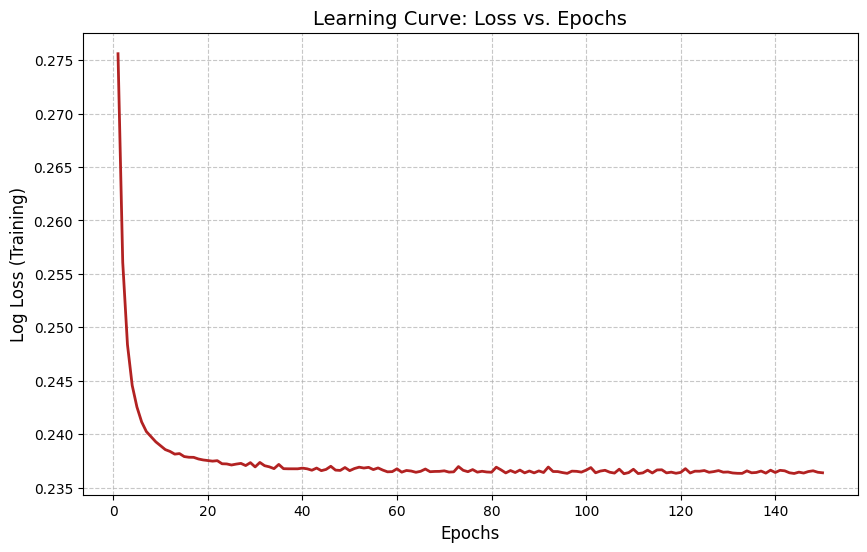

Final Loss at Epoch 150: 0.2364


In [ ]:
# Check learning curve
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(pilot_model.loss_history_) + 1),
    pilot_model.loss_history_,
    color="firebrick",
    linewidth=2,
)

plt.title("Learning Curve: Loss vs. Epochs", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Log Loss (Training)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

print(f"Final Loss at Epoch 150: {pilot_model.loss_history_[-1]:.4f}")

Evidently, the loss flattens around 40+ epochs. Thus, the safe set
of epochs determined will be 50.

### Hyperparameter Tuning

After determining the ideal epoch (50), it will then be set as a fixed
hyperparameter for the hyperparameter tuning phase. This avoids overfitting
and applies the least validation loss. First, instantiate a `Pipeline()` object
that consists of standardization, followed by the model. Then, set the
parameter ranges, where `logreg_batch_size` is randomly selected from the
ranges of 32, 64, and 128, and then the learning rate (`logreg_eta0`) from
0.0001 to 0.1. The selected iterations will also be 50, allowing for a broad
range of possible combinations.

In [ ]:
# Perform hyperparameter tuning
# Instantiate pipeline with SGDWrapper
pipeline = Pipeline([("scaler", StandardScaler()),
                    ("logreg", MinibatchSGDWrapper())])

# Define hyperparameter ranges
param_dist = {
    "logreg__eta0": loguniform(1e-4, 1e-1),
    #
    "logreg__batch_size": [32, 64, 128],
    # Set best epochs
    "logreg__epochs": [50],
}

# RandomizedSearchCV is more robust than manual iterations as the former runs jobs in parallel
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

After instantiations, perform hyperparameter tuning.

In [ ]:
# Tune hyperparameter via random_search
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\Rohann\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...GDWrapper())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'logreg__batch_size': [32, 64, ...], 'logreg__epochs': [50], 'logreg__eta0': <scipy.stats....00266373B88F0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0

The `Pipeline()` shows the parameters of each step in its process.

#### Best Hyperparameters

After hyperparameter tuning, log the parameters of the model with the lowest loss.

In [ ]:
# Log best model
best_model = random_search.best_estimator_

print(f"Best Params: {random_search.best_params_}")
print(f"Best CV Accuracy: {random_search.best_score_:.4f}")

Best Params: {'logreg__batch_size': 64, 'logreg__epochs': 50, 'logreg__eta0': 0.0018856783874794994}
Best CV Accuracy: 0.8995


From the results, a learning rate (`logreg_eta0`) of 0.001886 and a `logreg_batch_size` of 64 yielded a cross-validation accuracy of 0.8995, which `RandomizedSearchCV` dictated to be the best hyperparameters for the model and its data.

#### Results

Load results into a dataframe for matplot and seaborn visualizations.

In [ ]:
# Load results into a df
results_df = pd.DataFrame(random_search.cv_results_)
results_df["param_logreg__eta0"] = pd.to_numeric(
    results_df["param_logreg__eta0"])
results_df["param_logreg__epochs"] = pd.to_numeric(
    results_df["param_logreg__epochs"])
results_df["param_logreg__batch_size"] = pd.to_numeric(
    results_df["param_logreg__batch_size"]
)

#### Impact of adjusting the learning rate on accruacy

Shown is the impact of learning rate on the model's `mean_test_score` across 50 iterations.

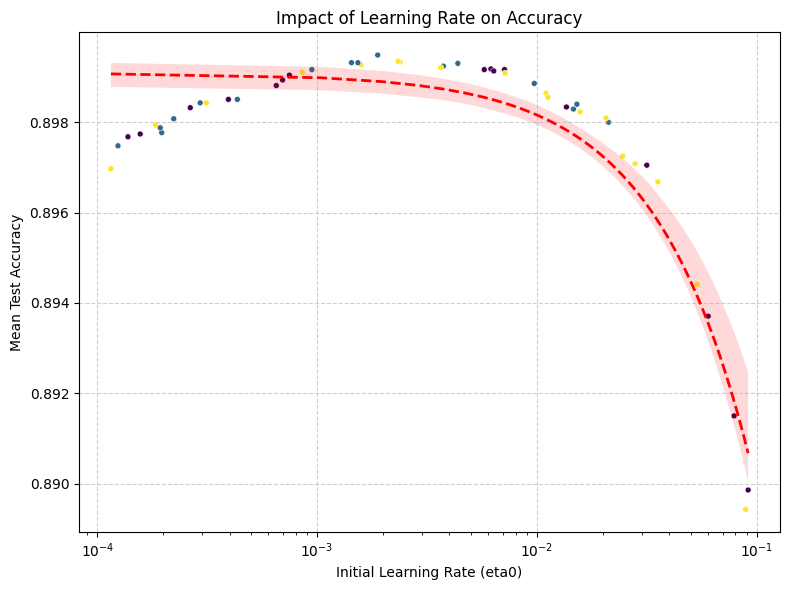

In [ ]:
# Impact of adjusting the learning rate on accruacy
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=results_df,
    x="param_logreg__eta0",
    y="mean_test_score",
    hue="param_logreg__batch_size",
    palette="viridis",
    size=200,
    legend=False,
)
sns.regplot(
    data=results_df,
    x="param_logreg__eta0",
    y="mean_test_score",
    scatter=False,
    order=1,  # Uses polynomial regression instead of LOWESS
    color="red",
    line_kws={"linestyle": "--", "linewidth": 2},
)

plt.xscale("log")
plt.title("Impact of Learning Rate on Accuracy")
plt.xlabel("Initial Learning Rate (eta0)")
plt.ylabel("Mean Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

The peak accuracy can be achieved using a learning rate of **0.001 to 0.005**. The model's accuracy falls off in a sharp curve from 0.01 and more, while a slower decreasing curve from 0.001 and less.

#### Impact of adjusting the batch size on accruacy

Shown is the impact of batch size on the model's `mean_test_score` across 50 iterations.

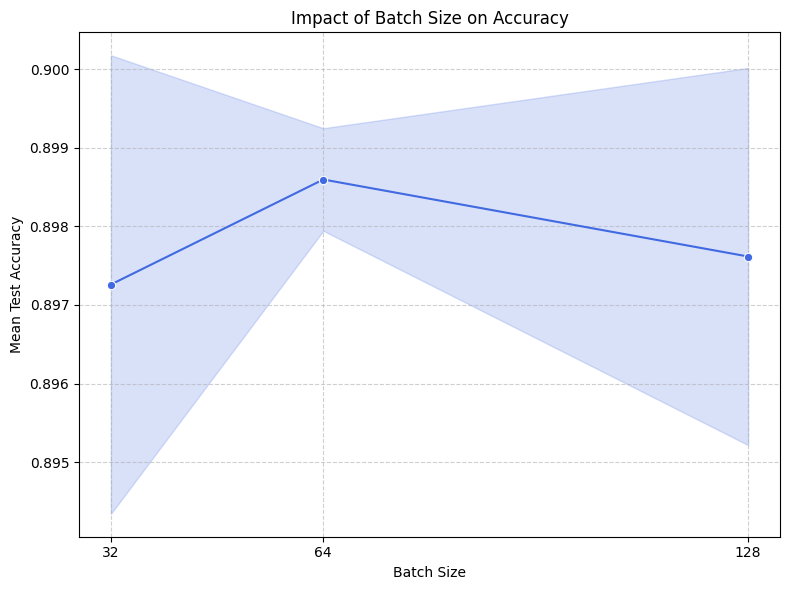

In [ ]:
# Impact of batch size on accuracy
plt.figure(figsize=(8, 6))

sns.lineplot(
    data=results_df,
    x="param_logreg__batch_size",
    y="mean_test_score",
    marker="o",
    color="royalblue",
    errorbar="sd",  # Shows the standard deviation as a shaded band
)

# Forces the x-axis to only show your exact batch sizes
plt.xticks([32, 64, 128])
plt.title("Impact of Batch Size on Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Mean Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

The `mean_test_score` of the model appears higher at batch sizes of 64. Thus, this will be concluded as the best batch size for the model.

## Model Testing and Results

After the model is trained on 70% of the data and validated on 15%, it will be tested on the remaining 15%.

### Classification Report on test set

A classification report is automatically generated based on the model's performance on its predictions on `X_test`.

In [ ]:
# Test best model on test data
y_pred_test = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_pred_test))

Test Accuracy: 0.8950

Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      5353
           1       0.89      0.92      0.90      6151

    accuracy                           0.89     11504
   macro avg       0.90      0.89      0.89     11504
weighted avg       0.90      0.89      0.89     11504



The model has an **89%** accuracy, hence it predicted 9/10 times. The `f1-score` is also placed 89% and 90% respectively for loss and wins, showcasing an exceptionally balanced model. There is also no evident case of overfitting in the results.

### Confusion Matrix on test set

The confusion matrix helps us visualize the quantifiable loss.

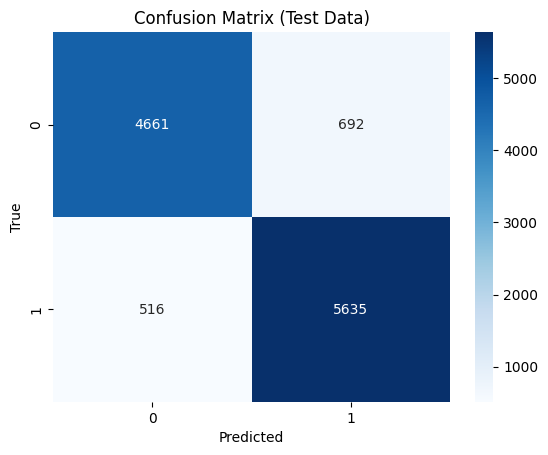

In [ ]:
# Test set confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Out of the 11,000+ instances, **only 1208** were falsely predicted.

### Probabilities for predictions

This section shows the probability confidence of the model. The sigmoid function
produces a probability from 0-1, and this value determines the final
classification. By default, any result with a _P(Win)_ >= 0.5
is labeled a match won (1), while anything below is a match lost (0).

In [ ]:
# Predictions on test set
# SGDClassifier supports the `predict_proba` method for estimating probabilities
y_proba = best_model.predict_proba(X_test)

# Display head predictions with probabilities
print("Predicted Probabilities (First 5 Test Examples):\n")
for i, (prob_0, prob_1) in enumerate(y_proba[:5]):
    print(f"Example {i+1}: P(Loss)={prob_0:.4f}, P(Win)={prob_1:.4f}")

Predicted Probabilities (First 5 Test Examples):

Example 1: P(Loss)=0.9839, P(Win)=0.0161
Example 2: P(Loss)=0.0297, P(Win)=0.9703
Example 3: P(Loss)=0.0093, P(Win)=0.9907
Example 4: P(Loss)=0.4710, P(Win)=0.5290
Example 5: P(Loss)=0.4170, P(Win)=0.5830


The probabilities produced by the model can be differentiated into two:

- High confidence, where probability of winning or losing is 95%+. This
  means that the model interpreted the match statistics as one-sided, where
  a player completely swept their opponent.
- Medium confidence, with probabilities ranging from 40-60%. This means
  that the model interpreted the match statistics as a close fight, where
  two players are going head-to-head with attacks.

### Feature weights

The weights of the features help us understand what factors in Tetrio
contribute to winning.

In [ ]:
# Feature impact
inner_model = best_model.named_steps["logreg"].model
feature_weights = inner_model.coef_[0]

# Map weights to feature names
feature_importances = pd.Series(data=feature_weights, index=X.columns).sort_values(
    ascending=False
)

print("Top 5 Positive Features (Increase P(Win)):\n")
print(feature_importances.head())

print("-" * 30)

print("Top 5 Negative Features (Increase P(Loss)):\n")
print(feature_importances.tail().sort_values(ascending=True))

Top 5 Positive Features (Increase P(Win)):

attack_per_piece    3.096458
combo_mean          1.796626
apm                 0.950279
pps                 0.330118
glicko_rd           0.077784
dtype: float64
------------------------------
Top 5 Negative Features (Increase P(Loss)):

incoming_garbage_mean   -6.130478
tspin_rate              -1.102873
btb_mean                -1.011536
combo_max               -0.989655
incoming_garbage_max    -0.426271
dtype: float64


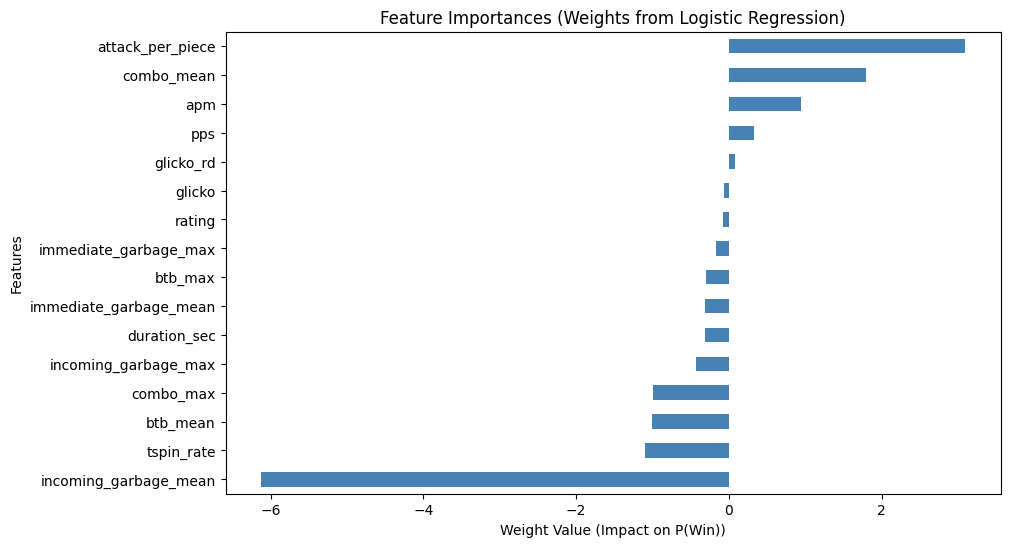

In [ ]:
# Feature impact visualization
plt.figure(figsize=(10, 6))
feature_importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importances (Weights from Logistic Regression)")
plt.xlabel("Weight Value (Impact on P(Win))")
plt.ylabel("Features")
plt.show()

From the determined feature weights, we can clearly visualize what
contributes to winning in a Tetrio match:

- `attack_per_piece`: **The abundance of attacks in a match is the
  most positive contributor** to winning a Tetrio match. `pps` or
  pieces per second dictates how often a player places a piece in
  a match. With its feature importance weighed at only 0.33, it goes
  to show that **efficiency (better attacks) wins more matches** than
  quickly placing pieces.
- `incoming_garbage`: The amount of garbage received in a match
  is the **most dominant contributor to losing**. Receiving a large
  amount of garbage tends to lead to losses. This suggests that the
  model is very sensitive to a player's inability to clear garbage.
  If a player fails to clear garbage despite a high `attack_per_piece`,
  then they are likely to lose.
- `combo_mean` vs. `combo_max`: `combo_mean` is the second-highest
  positive contributor to winning. Thus, **maintaining a higher average combo
  leads to better chances of winning** in a Tetrio match. On the other hand,
  `combo_max` is a negative contributor. Decisions such as going for a quad
  (4-wide clear) or t-spin triple at crucial moments are riskier moves that
  can leave a player vulnerable to counter-spikes (massive `incoming_garbage`).
- `tspin_rate` & `btb_mean`: High attack moves, such as t-spins and back-to-back
  moves turn out to be negative contributors. This does not mean that such moves
  are considered negative, but rather that **prioritizing flashy setups can be very risky
  for a player**. It may remove their defensive timing and leave them open to `incoming_garbage`.

## Neural Network

### Data Preparation

#### Train-Validation-Test Split

We settled on a **70/15/15** split for training, validation, and testing. This is a highly effective split given the size of our dataset (70,000+ rows). Allocating 70% ensures the models have ample examples to learn complex patterns and generalize well. Allocating 15% (roughly 10,500 rows) to the validation set provides a statistically significant sample for tuning hyperparameters without overfitting. Finally, leaving an untouched 15% test set ensures a robust and unbiased final evaluation of our models.

In [19]:
X = df.drop(columns=['won'])
y = df['won']

# train split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# validation and test split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

In [20]:
print(f"Training set:   X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation set: X_val={X_val.shape},   y_val={y_val.shape}")
print(f"Test set:       X_test={X_test.shape},   y_test={y_test.shape}")

Training set:   X_train=(49172, 16), y_train=(49172,)
Validation set: X_val=(10537, 16),   y_val=(10537,)
Test set:       X_test=(10537, 16),   y_test=(10537,)


#### Feature Scaling

As observed in our exploratory data analysis, it is essential to perform feature scaling on the data before proceeding to perform the machine learning task. Specifically, fitting the scaler only on the training data then transforming the validation and test sets because doing otherwise causes data leakage. Data leakage occurs when information from outside the training dataset accidentally influences the training process.

The core principle of machine learning evaluation is that the test and validation sets must represent completely unseen, real-world data and if we fit the scaler on the entire dataset before splitting, the statistical properties of the test set will influence how the training data is scaled. This allows the model to subtly 'peek' at the test set during training, leading to falsely inflated performance metrics that will not hold up when the model is evaluated on new Tetrio matches

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

X_train_scaled_df.head()

,btb_mean,btb_max,combo_mean,combo_max,immediate_garbage_mean,immediate_garbage_max,incoming_garbage_mean,incoming_garbage_max,rating,glicko,glicko_rd,duration_sec,pps,attack_per_piece,apm,tspin_rate
0,0.147545,0.434367,0.602830,0.481704,0.730153,1.407690,0.717789,0.927207,-0.029996,-0.448267,-0.062229,0.439384,-0.580616,0.443373,-0.033624,-0.003530
1,-0.799646,-0.767129,2.576991,0.992814,1.022950,0.661311,1.643701,0.476322,0.102598,-0.360330,-0.592878,-0.566186,-0.549027,0.421217,-0.030042,0.364850
2,0.098646,0.133993,-1.381681,-1.051625,-0.470950,-0.831447,-0.674647,-1.101777,-2.161196,-1.259941,3.069345,-0.639540,0.624907,-0.406538,-0.039800,1.103770
3,-0.880399,-0.767129,0.602830,0.992814,-0.482456,-0.831447,-0.632948,-0.876334,-1.544111,-1.105867,-0.771944,0.931477,0.271714,-1.150269,-0.803090,-1.228396
4,-0.038588,0.133993,0.384931,-0.029406,-0.321984,-0.333861,-0.435367,-0.650892,-1.013997,-0.930327,-0.636514,0.300367,-0.655918,0.775148,0.144130,0.552553


---

### Neural Network Implementation

Going into the specifics of the architecture of the neural network we used, the hidden layers utilizes the **ReLu (Rectified Linear Unit)** activation functions, which is computationally efficient and mitigates the vanishing gradient problem, allowing the network to learn deeper complex relationships between gameplay statistics. As mentioned earlier, a **Sigmoid** activation function in the output layer is used for binary classification. Finally, the network is optimized using **Adam**, as its adaptive learning rates generally provide faster and more reliable convergence on tabular data compared to standard gradient descent.

In [23]:
torch.manual_seed(0)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1) 

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.to_numpy(), dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

#### Training Flow

The step-by-step process of how this neural network uses the data's variables is as follows:

- Epoch iteration: The model trains for a set value of 150 epochs wherein each epoch, the model sees the entire training dataset

- Mini-batching: Only a batch of the training data is used, which speeds up convergence and requires less memory than passing the entire dataset at once

- Forward pass: for each batch, the data is passed through the network, outputting raw score predictions

- Loss calculation: the predicted scores are compared against the actual match outcomes using the BCE (binary cross entropy) criterion

- Backward ppass (Backpropagation): calculates the gradients or how much each weight contributed to the error

- Weight update: the optimizer adjusts the network's weights based on the calculated gradients to reduce future errors

- Epoch validation: After processing all batches, the model switches to evaluation mode and calculates calculates the average loss and accuracy across both the full training set and the validation set

Additionally, the collected metrics are plotted to visually verify that the model is learning and to check for overfitting (validation loss diverging from training loss)

Training Accuracy: 0.9106
Validation Accuracy: 0.9073


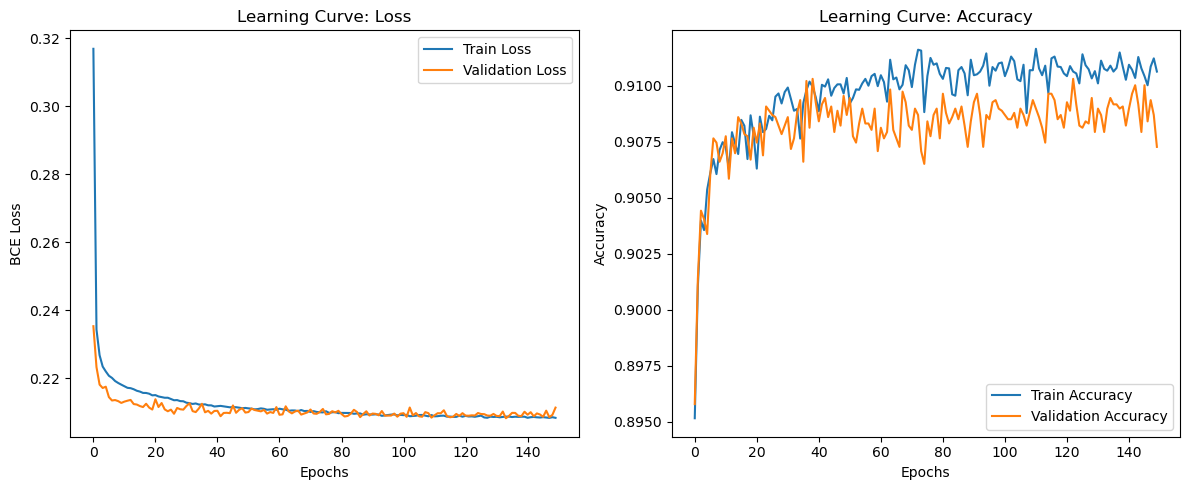

In [36]:
learning_rate = 0.001
hidden_layers = [16]
batch_size = 32

network = NeuralNetwork(input_size=X_train_t.shape[1], num_classes=1, list_hidden=hidden_layers, activation='relu')
network.create_network()
network.init_weights()

optimizer = optim.Adam(params=network.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss()
data_loader = DataLoader(X_train_t.numpy(), y_train_t.numpy(), batch_size=batch_size)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(150):
    network.train()
    X_batch, y_batch = data_loader.get_batch(mode='train')
    
    epoch_train_loss = 0
    for X_b, y_b in zip(X_batch, y_batch):
        X_b = torch.tensor(X_b, dtype=torch.float32)
        y_b = torch.tensor(y_b, dtype=torch.float32)
        
        optimizer.zero_grad()
        scores, _ = network.forward(X_b)
        loss = criterion(scores, y_b)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(X_batch)
    train_losses.append(avg_train_loss)
    
    network.eval()
    with torch.no_grad():
        t_scores, _ = network.forward(X_train_t)
        t_loss = criterion(t_scores, y_train_t).item()
        t_preds = (torch.sigmoid(t_scores) >= 0.5).float()
        train_accs.append((t_preds == y_train_t).float().mean().item())
        
        v_scores, _ = network.forward(X_val_t)
        v_loss = criterion(v_scores, y_val_t).item()
        val_losses.append(v_loss)
        v_preds = (torch.sigmoid(v_scores) >= 0.5).float()
        val_accs.append((v_preds == y_val_t).float().mean().item())

print(f"Training Accuracy: {train_accs[-1]:.4f}")
print(f"Validation Accuracy: {val_accs[-1]:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Learning Curve: Loss")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title("Learning Curve: Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Observing the difference between the training accuracy (91.06%) and validation accuracy (90.73%), a 0.33% margin is healthy and acceptable. It successfully mapped out complex relationships in the data, and the model shows that it is able to generalize on unseen data, not just memorizing the training set.

The loss curve on the left tells us that in the first 10-20 epochs, both lines plummet and the optimizer is quickly finding the obvious patterns in the data. Eventually, the training and validation loss hug each other very closely throughout. It can also be concluded that no severe overfitting wherein the validation loss curve (orange) does not fluctuate wildly towards the end and tells us that the model is generalizing well.

The accuracy curve for training and validation shows that it tends to hover around 90% - 91% accuracy, suggesting excellent performance. Although there are clear gaps between the curves, these are just minor amounts of overfitting and not very concerning.

Given this setup of neural network with one hidden layer, it already shows remarkable results. However, other configurations must still be explored to check whether a performance could be achieved.

#### Hyperparameter Tuning and Analysis

In terms of the hyperparameters, we settled with the following: 
- A learning rate of 0.001, as we believe it offers an excellent balance between the speed of convergence and stability

- Multiple configurations of hidden layers with differing amounts of hidden layers themselves and the neuron within those hidden layers. As the single previous iteration uses only one hidden layers, we decided to test out 2-4 hidden layers and observe whether a shallow network is sufficient or if a deeper network may be necessary. The idea behind the amount of neurons is to be proportionate with the amount of features (16), then the sequence mostly uses a funneling amount, or reducing neurons in successive layers, to compress information into higher-level abstract features. This bottleneck reduces computational load and limits the number of learnable parameters, which prevents overfitting

- Batch sizes of 32 and 64 were used, which we believe are not too big or too small

Still using a set max epoch value of 150, an iteration through the different combinations of these hyperparameters is what consistitutes this tuning phase

Furthermore, training and validation accuracy were calculated for each hyperparameter configuration to easily analyze the differences between them. The identified optimal model also undergoes qualitative analysis to understand its blind spots, specifically using a confusion matrix to map predicted outcomes against true outcomes and extracting the false positives and false negatives. This is also accompanied by plotting a learning curve.

Testing Config - Learning Rate: 0.001, Hidden Layers: [16, 8], Batch Size: 32
Training Accuracy: 0.9127 | Validation Accuracy: 0.9073

Testing Config - Learning Rate: 0.001, Hidden Layers: [16, 8], Batch Size: 64
Training Accuracy: 0.9119 | Validation Accuracy: 0.9060

Testing Config - Learning Rate: 0.001, Hidden Layers: [32, 16], Batch Size: 32
Training Accuracy: 0.9159 | Validation Accuracy: 0.9060

Testing Config - Learning Rate: 0.001, Hidden Layers: [32, 16], Batch Size: 64
Training Accuracy: 0.9150 | Validation Accuracy: 0.9049

Testing Config - Learning Rate: 0.001, Hidden Layers: [8, 4], Batch Size: 32
Training Accuracy: 0.9093 | Validation Accuracy: 0.9066

Testing Config - Learning Rate: 0.001, Hidden Layers: [8, 4], Batch Size: 64
Training Accuracy: 0.9101 | Validation Accuracy: 0.9063

Testing Config - Learning Rate: 0.001, Hidden Layers: [16, 8, 4], Batch Size: 32
Training Accuracy: 0.9127 | Validation Accuracy: 0.9078

Testing Config - Learning Rate: 0.001, Hidden Layers

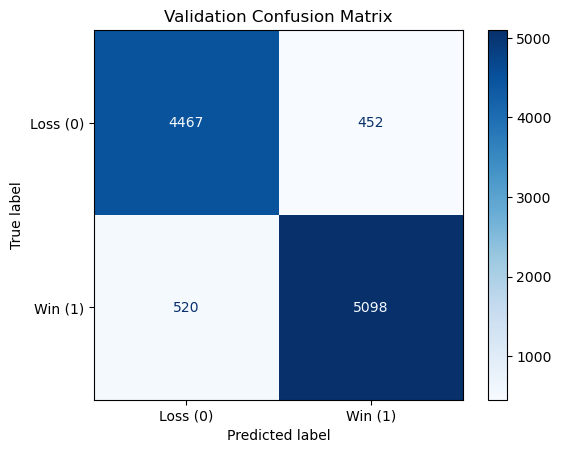

Validation False Positives (Predicted Win, Actually Lost): 452
Validation False Negatives (Predicted Loss, Actually Won): 520


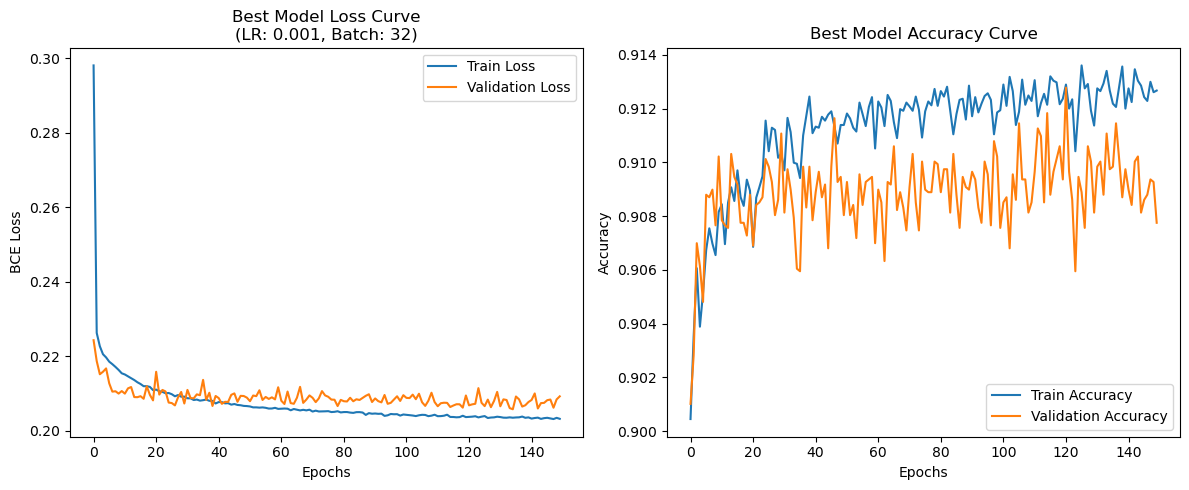

In [37]:
learning_rate = [0.001]
hidden_layers = [
    [16, 8], [32, 16], [8, 4],
    [16, 8, 4], [32, 16, 8], [16, 16, 8],
    [32, 16, 8, 4]
]
batch_sizes = [32, 64]

best_val_accuracy = 0
best_params = {}
best_model_state = None

for lr, h_layers, batch_size in itertools.product(learning_rate, hidden_layers, batch_sizes):
    print(f"Testing Config - Learning Rate: {lr}, Hidden Layers: {h_layers}, Batch Size: {batch_size}")
    network = NeuralNetwork(input_size=X_train_t.shape[1], num_classes=1, list_hidden=h_layers, activation='relu')
    network.create_network()
    network.init_weights()

    optimizer = optim.Adam(params=network.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    data_loader = DataLoader(X_train_t.numpy(), y_train_t.numpy(), batch_size=batch_size)

    temp_train_loss, temp_val_loss = [], []
    temp_train_acc, temp_val_acc = [], []

    for epoch in range(150):
        network.train() 
        X_batch, y_batch = data_loader.get_batch(mode='train')

        epoch_train_loss = 0

        for X_b, y_b in zip(X_batch, y_batch):
            X_b = torch.tensor(X_b, dtype=torch.float32)
            y_b = torch.tensor(y_b, dtype=torch.float32)
            optimizer.zero_grad()
            scores, _ = network.forward(X_b)
            loss = criterion(scores, y_b) 
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
    
        temp_train_loss.append(epoch_train_loss / len(X_batch))

        network.eval() 
        with torch.no_grad():
            train_scores, _ = network.forward(X_train_t)
            train_probs = torch.sigmoid(train_scores)
            train_predictions = (train_probs >= 0.5).float()
            train_correct = (train_predictions == y_train_t).sum().item()
            train_accuracy = train_correct / len(y_train_t)
            temp_train_acc.append(train_accuracy)

            val_scores, _ = network.forward(X_val_t)
            val_probs = torch.sigmoid(val_scores)
            val_predictions = (val_probs >= 0.5).float()
            val_correct = (val_predictions == y_val_t).sum().item()
            val_accuracy = val_correct / len(y_val_t)
            val_loss = criterion(val_scores, y_val_t).item()

            temp_val_loss.append(val_loss)
            temp_val_acc.append(val_accuracy)

    print(f"Training Accuracy: {train_accuracy:.4f} | Validation Accuracy: {val_accuracy:.4f}\n")
    
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_params = {'lr': lr, 'hidden_layers': h_layers, 'batch_size': batch_size}
        best_model_state = network.state_dict()

        best_history = {
            'train_loss': temp_train_loss,
            'val_loss': temp_val_loss,
            'train_acc': temp_train_acc,
            'val_acc': temp_val_acc
        }

print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Parameters: {best_params}")

final_network = NeuralNetwork(input_size=X_train_t.shape[1], num_classes=1, list_hidden=best_params['hidden_layers'], activation='relu')
final_network.create_network()
final_network.load_state_dict(best_model_state)
final_network.eval()

with torch.no_grad():
    best_val_scores, _ = final_network.forward(X_val_t)
    best_val_predictions = (torch.sigmoid(best_val_scores) >= 0.5).float()

cm = confusion_matrix(y_val_t.numpy(), best_val_predictions.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Loss (0)", "Win (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Validation Confusion Matrix")
plt.show()

false_positives = cm[0][1]
false_negatives = cm[1][0]
print(f"Validation False Positives (Predicted Win, Actually Lost): {false_positives}")
print(f"Validation False Negatives (Predicted Loss, Actually Won): {false_negatives}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Validation Loss')
plt.title(f"Best Model Loss Curve\n(LR: {best_params['lr']}, Batch: {best_params['batch_size']})")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history['train_acc'], label='Train Accuracy')
plt.plot(best_history['val_acc'], label='Validation Accuracy')
plt.title("Best Model Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Results show that the configuration with the **0.001 learning rate, [16, 8, 4] as its hidden layer setup and a batch size of 32**, acquiring an **accuracy of 90.78%**. Notably, the accuracies of the different hyperparameter configurations are very close to one another, ranging from 90.25% to 90.78% 

Specifically looking at the confusion matrix, it shows that there are 452 False Positives and 520 False Negatives. The false positives could mean that the player was dominating the match statistically but likely made a catastrophic misdrop at the top of the board, losing the game despite their high performance. Meanwhile, the false negatives could mean that the player was getting battered and had terrible offensive stats, but managed to survive just long enough for their opponent to make a fatal mistake and top out first.

Both the loss and accuracy plots also show stable learning. Although, jitters are clearly noticable in the validation curves, where it bounces up and down slightly from epoch to epoch, it is a normal effect of using a smaller batch size (32) as it introduces a little bit of noise into the gradient updates, which actually helps prevent the network from getting stuck in local minima and acts as a natural regularizer against overfitting.

Most importantly, the validation lines somewhat stay tightly bound to the training lines and there is no point where the validation loss violently curves upward, meaning this model is highly robust to unseen data.

It is also important to note that this type of data comes from human behavior, which inherently contains unpredictable variance, meaning that the accuracy is less likely to hit a much higher or almost perfect value.

Comparing the accuracy of this configuration (90.78%) to the single iteration performed earlier (90.73%), shows us that one hidden layer in the neural network setup is sufficient to perform predictions on new games and be able to achieve a reasonable accuracy.

#### Evaluation on Test Set

Finally, the best combination of hyperparameters identified during validation is used on unseen data. Moreover, a classification report is also generated to provide a comprehensive view of how the model performed on completely unseen gameplay data

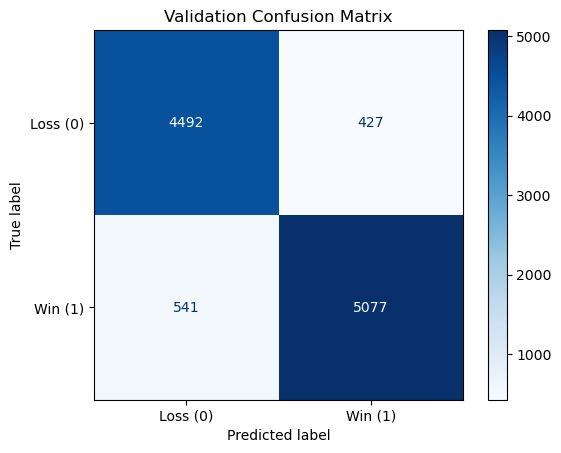

              precision    recall  f1-score   support

    Loss (0)     0.8925    0.9132    0.9027      4919
     Win (1)     0.9224    0.9037    0.9130      5618

    accuracy                         0.9081     10537
   macro avg     0.9075    0.9084    0.9078     10537
weighted avg     0.9085    0.9081    0.9082     10537



In [38]:
with torch.no_grad():
    test_scores, _ = final_network.forward(X_test_t)
    test_predictions = (torch.sigmoid(test_scores) >= 0.5).float()

cm = confusion_matrix(y_test_t.numpy(), test_predictions.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Loss (0)", "Win (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Validation Confusion Matrix")
plt.show()

print(classification_report(y_test_t.numpy(), test_predictions.numpy(), target_names=["Loss (0)", "Win (1)"], digits=4))

The classification report reveals that the neural network with the previously identified parameters performs exceptionally well on the completely unseen test data, achieving an overall **accuracy of 90.81%** across 10,537 matches.

Looking closely at the individual classes, we can see a slight asymmetry in how the model evaluates gameplay. For predicting a "Loss," the model has a high recall of 91.32%, meaning it successfully catches the vast majority of actual losing games. However, its precision for losses is slightly lower at 89.25%, indicating that the model is a bit quick to assume a game is a loss based on poor stats, occasionally mislabeling a victory as a loss.

On the other hand, when predicting a "Win," the model had a precision of 92.24%, meaning that when the network officially predicts a win, we can be highly confident it's correct wherein the player's statistical profile was undeniably dominant. Its recall for wins sits at 90.37%, showing that it misses a small chunk of actual wins, largely because it categorized those chaotic, low-efficiency victories as losses. Overall, the incredibly tight macro and weighted averages prove that the model is balanced and is not being artificially skewed by the dataset.

#### Permutation Feature Importance

This is performed to find which features did the model heavily rely on. Although neural networks are black boxes, permutation feature importance can applied, as it is a model-agnostic technique that measures a feature's importance by calculating the increase in a model's prediction error after randomly shuffling (permuting) that feature's values


Feature Importances:
               Feature  Importance
 incoming_garbage_mean    0.224162
      attack_per_piece    0.221031
immediate_garbage_mean    0.136946
            combo_mean    0.100598
                   apm    0.053621
              btb_mean    0.052482
          duration_sec    0.050394
            tspin_rate    0.045554
             combo_max    0.044035
                glicko    0.005979
                   pps    0.004840
  incoming_garbage_max    0.002467
               btb_max    0.002373
                rating    0.002183
 immediate_garbage_max    0.001424
             glicko_rd    0.000664


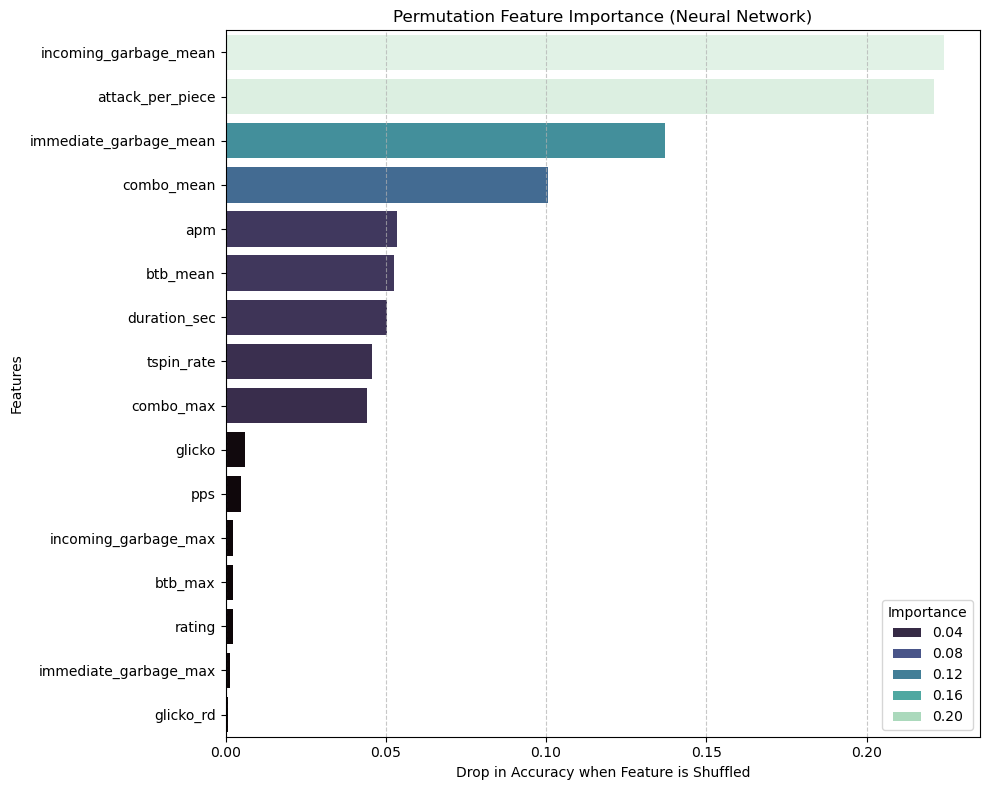

In [39]:
final_network.eval()

with torch.no_grad():
    base_scores, _ = final_network.forward(X_test_t)
    base_preds = (torch.sigmoid(base_scores) >= 0.5).float()
    base_acc = accuracy_score(y_test_t.numpy(), base_preds.numpy())

importances = []
num_features = X_test_t.shape[1]

try:
    feature_names = X.columns
except NameError:
    feature_names = [f"Feature {i}" for i in range(num_features)]

for i in range(num_features):
    X_test_shuffled = X_test_t.clone()
    
    shuffled_indices = torch.randperm(X_test_shuffled.size(0))
    X_test_shuffled[:, i] = X_test_shuffled[shuffled_indices, i]
    
    with torch.no_grad():
        shuffled_scores, _ = final_network.forward(X_test_shuffled)
        shuffled_preds = (torch.sigmoid(shuffled_scores) >= 0.5).float()
        shuffled_acc = accuracy_score(y_test_t.numpy(), shuffled_preds.numpy())
        
    drop_in_acc = base_acc - shuffled_acc
    importances.append(drop_in_acc)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df, 
    x='Importance', 
    y='Feature', 
    palette='mako',
    hue='Importance'
)
plt.title("Permutation Feature Importance (Neural Network)")
plt.xlabel("Drop in Accuracy when Feature is Shuffled")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


According to the results of the permutation feature importance, The model is overwhelmingly driven by `incoming_garbage_mean` and `attack_per_piece`. This makes sense because in order to predict a winner, the model needs to know exactly how much pressure the player was under, and how effectively the player translated their piece placements into damage. Although not as important, the model might rely on `tspin_rate` if two players have the exact same APM and incoming garbage, as executing complex T-Spins is generally demonstrating higher board control and is statistically more likely to secure the win.

The neural network strongly prefers average performance metrics over extreme peak metrics. `immediate_garbage_mean`, `combo_mean`, and `btb_mean` are all still solid predictors, and the model uses these to measure sustained, methodical pressure. Meanwhile, it recognizes the maximums as noise since `immediate_garbage_max`, `incoming_garbage_max`, and `btb_max` are almost entirely ignored, indicating that the model learned that absorbing one massive spike of garbage, or sending one massive 20-chain B2B, does not reliably dictate who wins the overall match. For `combo_max`, however, it is viewed as a red flag when it is a high value relating to the scatterplot in the exploratory data analysis where massive, extreme combo chains almost always belonged to losing players.

Additionally, `duration_sec` provides context to these averages and the model likely pairs it with the other metrics.

Other features that were deemed irrelevant are `pps`, `rating`, `glicko`, and `glicko_rd`. This tells us that raw speed was redundant noise and was ignored by the model, especially since it correlates with damage. Thus, it sees `attack_per_piece` and `apm` as better metrics. The same goes for ratings, which was ignored by the model.

## Evaluation and Comparison of Models Used

This section summarizes the results of the different models developed for the Tetr.io Top Players Replays dataset.

### Neural Network (NN)
* Best Validation Accuracy: **0.9078**
* Best Config: LR=0.001, Hidden Layers=[16, 8, 4], Batch Size=32
* Precision/Recall/F1: Balanced, with slightly higher win precision (0.9224) and slightly higher loss recall (0.9132)
* Strengths:
  * Highest accuracy among all models tested.
  * Feature importance indicates "incoming_garbage_mean" and "attack_per_piece" are most predictive.

**Notes:**
* Model is robust with multiple configurations showing strong performance.
* Overfitting appears minimal due to close training/validation scores.

### Logistic Regression (SGD/Minibatch):
* Best Test Accuracy: **0.8950**
* Top Positive Features (↑ Win): attack_per_piece, combo_mean, apm
* Top Negative Features (↑ Loss): incoming_garbage_mean, tspin_rate, btb_mean
* Strengths:
  * Very interpretable (feature coefficients point to aggression and defense as key).
  * High but slightly lower accuracy than NN.

**Notes:**
* Probability outputs are well-calibrated and match expected trends.

### k-Nearest Neighbors (kNN):
* Best Accuracy: **0.8696**
* Best k: 37 ('distance' weighting)
* Stability: Using k=37 provides much smoother and more reliable probability estimates than k=5.

**Notes:**
* Clear gap in performance compared to the NN and Logistic Regression, but still performs decently.
* Increasing k past 10 plateaus improvement; small k leads to instability.

### Results Table
| Model                   | Best Accuracy | Precision (0/1) | Recall (0/1) | F1 (0/1)   | Support (0/1) | Key Notes                                                      |
|-------------------------|---------------|-----------------|--------------|------------|----------------|---------------------------------------------------------------|
| Neural Network (NN)     | 0.9078        | 0.8925 / 0.9224 | 0.9132/0.9037| 0.9027/0.9130 | 4919/5618      | Best performance; robust across configs; top features: incoming_garbage_mean, attack_per_piece     |
| Logistic Regression     | 0.8950        | 0.90 / 0.89     | 0.87 / 0.92  | 0.89 / 0.90 | 5353 / 6151    | Interpretable, strong for attack/defense cues, slightly lower accuracy than NN                     |
| kNN (k=37, weighted)    | 0.8696        | 0.88 / 0.86     | 0.84 / 0.90  | 0.86 / 0.88 | 5353 / 6151    | Stable with higher k, plateau >k=20, less accurate than NN/logreg                                 |
| kNN (Baseline, k=5)     | 0.8526        | 0.85 / 0.85     | 0.83 / 0.87  | 0.84 / 0.86 | 5353 / 6151    | Higher probability extremes, less stable, lower accuracy                                           |

### Feature Importance Discussion

`incoming_garbage_mean`:
* `incoming_garbage_mean` appears as the most important feature in all models.
* EDA and feature importance results showed that players overwhelmed by sustained garbage are much more likely to lose, confirming the model’s emphasis on this metric.
* We recommend Tetr.io players to prioritize clearing garbage to increase chances of winning.

`attack_per_piece`:
* Attack efficiency is also a top contributor to winning.
* Players who send more garbage per piece have a distinct advantage.
* EDA and feature importance results showed that high impact attacks secure more wins.
* In relation to `pps` or pieces per second, `attack_per_piece` has a higher influence on model prediction. We can infer that being fast in placing pieces does not significantly contribute to winning but rather the amount of attacks within the given pieces.
* We recommend Tetr.io players to slow down piece placement if possible and organize a proper attack strategy.

**Consistency > Peak attacks**:
* Models value average stats (`combo_mean`, `btb_mean`, `immediate_garbage_mean`) over max stats (`combo_max`, `btb_max`, `immediate_garbage_max`).
* EDA and feature importance results showed that consistent pressure is a moderately significant contributor to winning.
* We recommend for Tetr.io players to avoid high spike (high attack) plays and go for sustained attacks through continuous combos.

`tspin_rates`:
* T-spins are popular and flashy Tetris moves.
* `tspin_rates` are less critical but may break ties if other stats are equal, indicating higher board control in close matches.

**Less important features**:
* `pps`, `rating`, and `glicko` were deemed unimportant by models.
* EDA and feature importance results also indicated that raw speed and ratings offer little additional value when performance stats (like APM/`attack_per_piece`) are available.

Both EDA and model results agree: handling incoming garbage and delivering steady, efficient attacks are key to winning. High-risk plays and raw speed are much less important than consistency and adaptability.

---

## Use of AI Tools

Statement: During the preparation of this work, the author(s) used Google Gemini 3 Pro for the following purposes:

1. Generating code snippets for the visualizations in the exploratory data analysis questions and checking the performance of the models

2. Optimizing our intially implemented functions for model training and validation

3. Generating the code for permutation feature importance in neural networks 

After using this tool/service, the author(s) reviewed, understood, and edited the generated code to ensure accuracy and alignment with the dataset and project goals. The author(s) take full responsibility for the final outputs and interpretations in this project.